# E-commerce Abnormal Order Detection with an Ensemble Model — Feature Engineering and Model Tuning (Part 2, Detailed Edition)

---

## Objectives of Part 2

1. Perform business-driven feature engineering by converting raw fields into numerical features that models can learn from.
2. Split training and test data correctly **by Order ID**, preventing transaction lines from the same order from leaking across the split.
3. Tune and combine tree-based models using AUC as the primary metric, producing an abnormal-order model suitable for operational risk alerts.

## Contents

1. Establish a benchmark with rough encoding and rapid cross-validation.
2. Split training and test sets by Order ID.
3. Perform field-by-field, business-driven feature engineering and encoding.
4. Build, tune, and combine models using voting and soft voting.

## 1. Establish a Benchmark

The objective is not to maximize model performance yet, but to obtain a quick and reproducible reference point.

### 1.1 Environment Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["axes.unicode_minus"] = False
N_JOBS = 4

In [2]:
data = pd.read_csv("data/abnormal_order2_en.csv")

# Translate the low-cardinality source values used in tables and charts.
# The fixed lists follow each field's first-appearance order in the source dataset.
value_translations = {
    "Product Category": [
        "Mobile, Photography & Digital", "TV, Refrigeration, Laundry & AC",
        "Furniture & Building Materials", "Household Essentials",
        "Computers, Office & Printing", "Sports & Outdoors",
        "Home, Kitchen & Small Appliances", "Food & Beverages",
        "Books & Audiovisual", "Beauty & Personal Care",
        "Maternal, Infant & Toys", "Home Textiles & Bedding",
        "Automotive Products", "Health & Medical", "Watches & Jewelry",
        "Apparel & Footwear", "Bags & Luxury Goods",
    ],
    "Order Channel": [
        "Main Site", "do.site_id", "Mobile Site", "Dangdang",
        "Group Buying", "Mobile Flash Sale", "Mobile Group Buying", "Flash Sale",
    ],
    "Payment Method": [
        "Combined Payment", "Dangdang Payment", "Cash on Delivery",
        "Account Balance", "Online Payment",
    ],
}

for column, translated_values in value_translations.items():
    source_values = data[column].drop_duplicates().tolist()
    data[column] = data[column].map(dict(zip(source_values, translated_values)))

In [3]:
data.columns

Index(['Order ID', 'Order Time', 'Product Category', 'Product Attribution',
       'Product ID', 'Brand', 'Order Amount', 'Quantity', 'Order Channel',
       'Payment Method', 'User ID', 'City', 'Abnormal Label'],
      dtype='object')

Before preprocessing, the features should be explored in detail to identify opportunities for useful business-driven transformations. The central modeling task is to distinguish abnormal transactions from ordinary ones. We therefore look for features that either increase separation between the two classes or quantify transaction risk.

The following fields are examined:

- Order Time
- Payment Method
- City
- Product Category, Product ID, and Brand
- User ID
- Order Amount and Quantity
- Order Channel and Product Attribution

Feature encoding must also be addressed. Although categorical variables are often handled with standard ordinal or one-hot encoding, those methods do not fit every production scenario. Each engineered field therefore requires an encoding strategy that can be reused on unseen data.

The first modeling step is a benchmark. The dataset contains many categorical features, so it must be encoded before being passed to a model. **The rigorous workflow is to split the data first, learn preprocessing rules on the training set, and then apply those rules to the test set.** For a rapid benchmark, however, we initially use `OrdinalEncoder` on the full dataset.

This shortcut is fast and provides a useful baseline, but it has two limitations:

> 1. **Data leakage:** fitting preprocessing on the full dataset exposes information from the test set, making validation results optimistic.
> 2. **No unseen-category strategy:** the fitted workflow cannot safely encode categories that appear only in future data.

This rough encoding is acceptable for a benchmark, but not for final training.

In [4]:
data.head()

,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
0,4283851335,14:09:49,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市,1
1,4276537082,14:16:47,"TV, Refrigeration, Laundry & AC",POP,8001992420,樱花,19900.0,100,Main Site,Combined Payment,qq-3be293b,泉州市,1
2,4281111595,10:44:46,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市,1
3,3977175284,23:26:19,"Mobile, Photography & Digital",POP,8002237611,伊斯贝,990.0,100,Main Site,Combined Payment,swt6263122,宁德市,0
4,4106833871,16:47:34,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市,0


### 1.2 Rough Encoding and a Random-Forest Benchmark

In [5]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier as RFC

In [6]:
oe = OrdinalEncoder()

In [7]:
X = data.iloc[:,1:-1]
y = data.iloc[:,-1]

In [8]:
X["Order Time"] = X["Order Time"].apply(lambda x:x[:2])

In [9]:
X.head()

,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City
0,14,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市
1,14,"TV, Refrigeration, Laundry & AC",POP,8001992420,樱花,19900.0,100,Main Site,Combined Payment,qq-3be293b,泉州市
2,10,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市
3,23,"Mobile, Photography & Digital",POP,8002237611,伊斯贝,990.0,100,Main Site,Combined Payment,swt6263122,宁德市
4,16,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市


In [10]:
X = pd.DataFrame(oe.fit_transform(X))

In [11]:
X.columns = data.iloc[:,1:-1].columns

In [12]:
X.head()

,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City
0,14.0,13.0,1.0,15907.0,227.0,3009.0,41.0,3.0,2.0,24870.0,5.0
1,14.0,15.0,1.0,15431.0,1551.0,2970.0,40.0,3.0,2.0,50713.0,207.0
2,10.0,7.0,1.0,18402.0,2049.0,621.0,40.0,3.0,2.0,46259.0,133.0
3,23.0,13.0,1.0,19080.0,377.0,1499.0,40.0,3.0,2.0,62154.0,101.0
4,16.0,11.0,1.0,18580.0,748.0,2799.0,40.0,3.0,2.0,56469.0,223.0


In [13]:
Xtrain,Xtest,Ytrain,Ytest = train_test_split(X,y,test_size=0.3,random_state=1412)

In [14]:
# Use standard K-fold cross-validation for the benchmark.

In [15]:
cv = KFold(n_splits=5,shuffle=True,random_state=1412)

In [16]:
# Accuracy.

In [17]:
clf = RFC(n_estimators=200,random_state=1412)

In [18]:
acc = cross_val_score(clf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS)

In [19]:
acc

array([0.81583243, 0.81392818, 0.81821644, 0.8119593 , 0.81348278])

In [20]:
acc.mean()

np.float64(0.81468382653453)

In [21]:
acc.var()

np.float64(4.647041631803535e-06)

In [22]:
# Area under the ROC curve.

In [23]:
auc = cross_val_score(clf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")

In [24]:
auc

array([0.82703898, 0.83301359, 0.83005422, 0.8244582 , 0.83001101])

In [25]:
auc.mean()

np.float64(0.8289152018369952)

In [26]:
auc.var()

np.float64(8.536011544590099e-06)

### 1.3 Benchmark Interpretation

- Mean five-fold accuracy is `0.81468`, with variance `4.65e-06`; the small variance indicates stable results across folds.
- Mean five-fold AUC is `0.82892`, with variance `8.54e-06`. AUC is more informative for ranking performance under class imbalance.
- These scores are **optimistic** because `fit_transform` was applied to the full dataset before validation.
- Subsequent feature engineering, tuning, and model fusion should clearly improve on this reference under a stricter split.

## 2. Train/Test Split by Order ID

An order can contain multiple transaction lines, and labels are almost always consistent within an order. If lines from the same order appear in both training and test data, the test stage is no longer independent and performance will be overstated.

### 2.1 Split Order IDs and Map the Split Back to Rows

A standard random row split is inappropriate here. Each row represents a product-level transaction line, several lines can form one order, and the labels within an order are consistent. Using some lines from an order to predict other lines from the same order would not be meaningful: **if one transaction line is abnormal, the whole order is effectively abnormal.**

The operational goal is to use historical orders to predict whether future orders will be abnormal. The split must therefore guarantee that no Order ID appears on both sides and that every test Order ID is unseen during training.

To achieve this, split the unique Order IDs first and then use those ID sets to construct row-level training and test data. Each order contains only about 1.15 rows on average, so a 70:30 ID split should also produce a row split close to 70:30.

In [27]:
data.groupby("Order ID").size().mean()

np.float64(1.1495092244783596)

First, split the unique Order IDs into training and test groups.

In [28]:
orderid = data["Order ID"].unique()

In [29]:
len(orderid) # Approximately 114,000 unique orders.

114207

In [30]:
# Reproduce the original seeded 70:30 Order-ID split efficiently.
import random

random.seed(1412)
test_id = random.sample(orderid.tolist(), int(len(orderid) * 0.3))
test_id_set = set(test_id)
train_id = [order_id for order_id in orderid if order_id not in test_id_set]

In [31]:
len(test_id)

34262

In [32]:
len(train_id)

79945

Next, label each row according to the Order-ID split.

In [33]:
data["Split"] = "train"

In [34]:
# Vectorized row assignment replaces the original multi-minute loop.
data.loc[data["Order ID"].isin(test_id), "Split"] = "test"

In [35]:
train = data.loc[data["Split"] == "train"].copy()
test = data.loc[data["Split"] == "test"].copy()

In [36]:
train.shape

(91868, 14)

In [37]:
test.shape

(39414, 14)

Calculate the realized row-level proportion and verify that it closely matches the ID-level split.

In [38]:
len(test) / (len(train) + len(test))  # Realized test-row share.

0.30022394539997865

In [39]:
# Reset indices and remove the temporary split marker.
for frame in [train, test]:
    frame.reset_index(drop=True, inplace=True)
    frame.drop(columns="Split", inplace=True)

In [40]:
train.shape

(91868, 13)

In [41]:
test.shape

(39414, 13)

In [42]:
train.head()

,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Abnormal Label
0,4283851335,14:09:49,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市,1
1,4281111595,10:44:46,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市,1
2,4106833871,16:47:34,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市,0
3,4253622967,21:15:59,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,Combined Payment,benson2570,宿迁市,0
4,4276159555,16:49:49,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,Combined Payment,dakehu_zy,西安市,0


In [43]:
# Move the target to the first column for later feature engineering.
Xtrain = train.iloc[:,:-1]
Xtest = test.iloc[:,:-1]
Ytrain = train.iloc[:,-1]
Ytest = test.iloc[:,-1]

In [44]:
train = pd.concat([Ytrain,Xtrain],axis=1)
test = pd.concat([Ytest,Xtest],axis=1)

In [45]:
train.head()

,Abnormal Label,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City
0,1,4283851335,14:09:49,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市
1,1,4281111595,10:44:46,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市
2,0,4106833871,16:47:34,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市
3,0,4253622967,21:15:59,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,Combined Payment,benson2570,宿迁市
4,0,4276159555,16:49:49,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,Combined Payment,dakehu_zy,西安市


In [46]:
test.head()

,Abnormal Label,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City
0,1,4276537082,14:16:47,"TV, Refrigeration, Laundry & AC",POP,8001992420,樱花,19900.0,100,Main Site,Combined Payment,qq-3be293b,泉州市
1,0,3977175284,23:26:19,"Mobile, Photography & Digital",POP,8002237611,伊斯贝,990.0,100,Main Site,Combined Payment,swt6263122,宁德市
2,0,4245023523,10:39:56,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市
3,0,4284515355,15:43:05,"Home, Kitchen & Small Appliances",POP,8001873245,佳星,21450.0,50,Main Site,Combined Payment,1382227461,广州市
4,0,4284735147,17:12:53,Household Essentials,POP,8002202146,奕辰,1950.0,50,Main Site,Combined Payment,sagggff,天津市


In [47]:
train.to_csv("data/train_bf_en.csv", index=False)
test.to_csv("data/test_bf_en.csv", index=False)

Feature engineering and modeling can now begin. **From this point forward, no information from the test set is used for exploration or rule learning.** All learned transformations come from the training data and are then applied to the test data; only objective transformations such as parsing time are shared directly.

### 2.2 Split Validation

- Each order contains an average of approximately `1.150` transaction lines, so splitting IDs and splitting rows produce similar proportions.
- The 114,207 unique orders are divided into 79,945 training orders and 34,262 test orders.
- The realized row-level test share is approximately `0.300`, as intended.
- Copies are created before mutation, avoiding ambiguous chained-assignment behavior.

## 3. Business-Driven Feature Engineering

The workflow for each field is:

1. Explore whether the feature behaves differently across normal and abnormal transactions.
2. Convert it into numerical form while ensuring that test data reuses rules learned from training data.

### 3.1 Order Time: Extract and Encode Hour and Minute

In [48]:
train = pd.read_csv("data/train_bf_en.csv")
test = pd.read_csv("data/test_bf_en.csv")

In [49]:
train.head()

,Abnormal Label,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City
0,1,4283851335,14:09:49,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市
1,1,4281111595,10:44:46,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市
2,0,4106833871,16:47:34,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市
3,0,4253622967,21:15:59,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,Combined Payment,benson2570,宿迁市
4,0,4276159555,16:49:49,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,Combined Payment,dakehu_zy,西安市


#### Relationship Exploration

In [50]:
import time
import datetime

In [51]:
# Extract the hour component as a separate Series.

In [52]:
train["Order Time"][0][:2]

'14'

In [53]:
order_hour = train["Order Time"].apply(lambda value: int(value[:2]))

In [54]:
# Count transactions within each hour.

In [55]:
order_time_abnormal = order_hour[train["Abnormal Label"] == 1].value_counts()

In [56]:
order_time_normal = order_hour[train["Abnormal Label"] == 0].value_counts()

In [57]:
import seaborn as sns

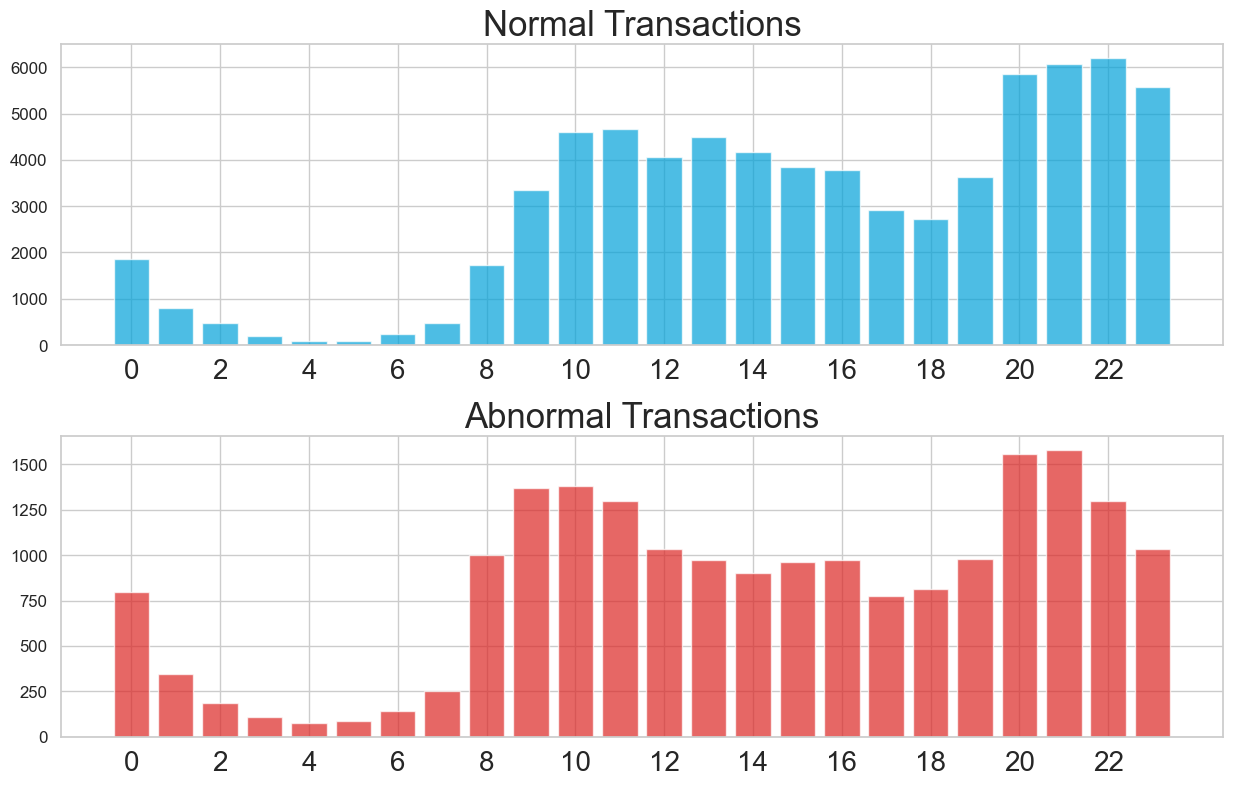

In [58]:
plt.figure(figsize=(15, 9), dpi=100)

plt.subplot(211)
plt.bar(order_time_normal.index, order_time_normal.values, color="#01a2d9", alpha=0.7)
plt.title("Normal Transactions", fontsize=25)
plt.xticks(ticks=range(0, 24, 2), fontsize=20)

plt.subplot(212)
plt.bar(order_time_abnormal.index, order_time_abnormal.values, color="#dc2624", alpha=0.7)
plt.title("Abnormal Transactions", fontsize=25)
plt.xticks(ticks=range(0, 24, 2), fontsize=20)

plt.subplots_adjust(hspace=0.3)
plt.show()

If order time were strongly associated with risk, abnormal transactions might cluster late at night or during other unusual hours. The distributions show no clear difference, suggesting that **Order Time is probably only weakly related to abnormality**.

The feature is nevertheless retained and split into hour and minute components. Hour is encoded over 24 categories, while minute is represented as a binary indicator for the first or second half of the hour.

#### Feature Encoding

In [59]:
train["Order Time"]

0        14:09:49
1        10:44:46
2        16:47:34
3        21:15:59
4        16:49:49
           ...   
91863    23:56:01
91864    23:57:24
91865    23:54:34
91866    23:55:06
91867    23:58:59
Name: Order Time, Length: 91868, dtype: object

#### Define Encoding Functions

In [60]:
def encode_minute_half(column, train, test, new_column="Order Minute Half"):
    """Encode minutes as first half-hour (0) or second half-hour (1)."""
    feature = train[column].apply(lambda value: int(value[3:5]) > 30)
    mapping = {category: code for code, category in enumerate(np.sort(feature.unique()))}

    train[new_column] = feature.map(mapping)
    test[new_column] = test[column].apply(lambda value: int(value[3:5]) > 30).map(mapping)
    return train, test

In [61]:
def encode_hour(column, train, test, new_column="Order Hour"):
    """Encode the hour component using a training-derived ordinal mapping."""
    feature = train[column].apply(lambda value: value[:2])
    mapping = {category: code for code, category in enumerate(np.sort(feature.unique()))}

    train[new_column] = feature.map(mapping)
    test[new_column] = test[column].apply(lambda value: value[:2]).map(mapping)
    return train, test

#### Step-by-Step Encoding Example

In [62]:
# Demonstrate the encoding steps with Order Minute Half.
feature = train.loc[:,"Order Time"].apply(lambda x: (int(x[3:5]) > 30))

In [63]:
feature.head()

0    False
1     True
2     True
3    False
4     True
Name: Order Time, dtype: bool

In [64]:
unique_ = np.sort(feature.unique())

In [65]:
unique_

array([False,  True])

In [66]:
dic = {} # Build the mapping dictionary.
for code, category in enumerate(unique_):
    dic[category] = code

In [67]:
dic

{np.False_: 0, np.True_: 1}

In [68]:
feature.map(dic)

0        0
1        1
2        1
3        0
4        1
        ..
91863    1
91864    1
91865    1
91866    1
91867    1
Name: Order Time, Length: 91868, dtype: int64

The same operation could be performed with scikit-learn's `OrdinalEncoder`. It is implemented manually here to prepare for later features that require custom unseen-category handling.

#### Apply the Encoding Functions

In [69]:
train, test = encode_minute_half("Order Time", train, test)
train, test = encode_hour("Order Time", train, test)

In [70]:
train.head()

,Abnormal Label,Order ID,Order Time,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour
0,1,4283851335,14:09:49,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市,0,14
1,1,4281111595,10:44:46,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市,1,10
2,0,4106833871,16:47:34,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市,1,16
3,0,4253622967,21:15:59,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,Combined Payment,benson2570,宿迁市,0,21
4,0,4276159555,16:49:49,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,Combined Payment,dakehu_zy,西安市,1,16


#### Remove the Original Order-Time Field

In [71]:
train.drop(columns="Order Time",inplace=True)
test.drop(columns="Order Time",inplace=True)

#### Save the Intermediate Data

In [72]:
train.to_csv("data/train_en.csv", index=False)
test.to_csv("data/test_en.csv", index=False)

### 3.2 Payment Method: Target-Mean Risk Encoding

In [73]:
#train = pd.read_csv(r'data/train_en.csv',index_col=0)
#test = pd.read_csv(r'data/test_en.csv',index_col=0)

The dataset contains five payment methods, and their abnormal-order risks may differ. Fabricated or malicious orders may favor simple combined or online payments. Cash on delivery is often available only to trusted users, so its fraud risk may be lower, although it can still carry logistics risk.

The main measure is the **abnormal rate**, defined as abnormal transactions divided by all transactions within a category. A higher abnormal rate indicates greater observed risk. The rate can be calculated for every category of a feature to evaluate its relationship with the target.

In [74]:
train["Payment Method"].value_counts()

Payment Method
Combined Payment    71893
Cash on Delivery    18321
Dangdang Payment     1226
Online Payment        290
Account Balance       138
Name: count, dtype: int64

In [75]:
train.groupby("Payment Method")["Abnormal Label"].mean()

Payment Method
Account Balance     0.028986
Cash on Delivery    0.000000
Combined Payment    0.275173
Dangdang Payment    0.044861
Online Payment      0.251724
Name: Abnormal Label, dtype: float64

In [76]:
dict(train.groupby("Payment Method")["Abnormal Label"].mean())

{'Account Balance': np.float64(0.028985507246376812),
 'Cash on Delivery': np.float64(0.0),
 'Combined Payment': np.float64(0.27517282628350465),
 'Dangdang Payment': np.float64(0.044861337683523655),
 'Online Payment': np.float64(0.2517241379310345)}

Combined payment and online payment have abnormal rates above 25%, while the remaining methods are much lower. This rate can be added as an **aggregate feature**. Aggregate features are created by grouping on a categorical variable and assigning each category a value with business meaning. Such features often improve tree and ensemble models substantially when they are constructed without leakage.

The following function calculates a training-set abnormal rate and maps it to both datasets.

In [77]:
def GroupByFeature(column,train,test,newcolumn):
    
    # Create the mapping from training data only.
    dic = dict(train.groupby(column)["Abnormal Label"].mean())
    
    # Create the new feature.
    train[newcolumn] = train[column].map(dic)
    test[newcolumn] = test[column].map(dic)
    
    return train, test

In [78]:
train,test = GroupByFeature("Payment Method",train,test,"Payment Method Risk Rate")

In [79]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate
0,1,4283851335,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,Combined Payment,dakehu_zy,上海市,0,14,0.275173
1,1,4281111595,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市,1,10,0.275173
2,0,4106833871,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,Combined Payment,qq-edf69d7,深圳市,1,16,0.275173
3,0,4253622967,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,Combined Payment,benson2570,宿迁市,0,21,0.275173
4,0,4276159555,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,Combined Payment,dakehu_zy,西安市,1,16,0.275173


In [80]:
test.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate
0,1,4276537082,"TV, Refrigeration, Laundry & AC",POP,8001992420,樱花,19900.0,100,Main Site,Combined Payment,qq-3be293b,泉州市,0,14,0.275173
1,0,3977175284,"Mobile, Photography & Digital",POP,8002237611,伊斯贝,990.0,100,Main Site,Combined Payment,swt6263122,宁德市,0,23,0.275173
2,0,4245023523,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,Combined Payment,nonscorpio,广州市,1,10,0.275173
3,0,4284515355,"Home, Kitchen & Small Appliances",POP,8001873245,佳星,21450.0,50,Main Site,Combined Payment,1382227461,广州市,1,15,0.275173
4,0,4284735147,Household Essentials,POP,8002202146,奕辰,1950.0,50,Main Site,Combined Payment,sagggff,天津市,0,17,0.275173


#### Encode the Original Payment-Method Category

In [81]:
def encodePay(column,train,test):
    "Encode the Payment Method field."
    
    dic = {}
    feature = train.loc[:,column]
    unique_ = np.sort(feature.unique())
    for code, category in enumerate(unique_):
        dic[category] = code
        
    # Replace the source feature when required.
    train[column] = train[column].map(dic)
    
    # Transform the test set with the training-derived mapping.
    test[column] = test[column].map(dic)
    
    return train,test

In [82]:
train,test = encodePay("Payment Method",train,test)

In [83]:
train["Payment Method"].value_counts()

Payment Method
2    71893
1    18321
3     1226
4      290
0      138
Name: count, dtype: int64

#### Save the Updated Features

In [84]:
train.to_csv("data/train_en.csv", index=False)
test.to_csv("data/test_en.csv", index=False)

#### Interpretation: Payment-Method Risk

Training-set abnormal rates are approximately:

| Payment method | Abnormal rate |
|---|---:|
| Combined payment | 0.2752 |
| Online payment | 0.2517 |
| Dangdang payment | 0.0449 |
| Account balance | 0.0290 |
| Cash on delivery | 0.0000 |

Combined and online payments are clearly riskier in this sample, supporting the use of `groupby(Payment Method)[Abnormal Label].mean()` as a risk feature. This is target-mean encoding and must be calculated on training data only before being mapped to test data.

### 3.3 City: Map to Province and Encode Provincial Risk

In [85]:
#train = pd.read_csv(r'data/train_en.csv',index_col=0)
#test = pd.read_csv(r'data/test_en.csv',index_col=0)

Delivery location is not expected to determine transaction abnormality directly, but its relationship with risk can still be assessed. City has 365 categories—too many for a clear aggregate comparison—so the cities are first grouped into provinces and the risk analysis is performed at the provincial level.

#### Map Cities to Provinces

In [86]:
city_reference = pd.read_excel("data/ChinaCity.xls", index_col=1)
city_reference.columns = ["Province"]

# Translate provinces by their stable first-appearance order in the reference table.
province_names = [
    "Beijing", "Tianjin", "Hebei", "Shanxi", "Inner Mongolia", "Liaoning",
    "Jilin", "Heilongjiang", "Shanghai", "Jiangsu", "Zhejiang", "Anhui",
    "Fujian", "Jiangxi", "Shandong", "Henan", "Hubei", "Hunan",
    "Guangdong", "Guangxi", "Hainan", "Chongqing", "Sichuan", "Guizhou",
    "Yunnan", "Tibet", "Shaanxi", "Gansu", "Qinghai", "Ningxia", "Xinjiang",
]
province_source_values = city_reference["Province"].drop_duplicates().tolist()
city_reference["Province"] = city_reference["Province"].map(
    dict(zip(province_source_values, province_names))
)

In [87]:
city_reference

,Province
市级,
北京市,Beijing
天津市,Tianjin
石家庄市,Hebei
唐山市,Hebei
秦皇岛市,Hebei
...,...
辽宁省其他城市,Liaoning
四川省其他城市,Sichuan
广东省其他城市,Guangdong


In [88]:
# A Series is convenient for constructing the city-to-province mapping.
city_reference["Province"]

市级
北京市          Beijing
天津市          Tianjin
石家庄市           Hebei
唐山市            Hebei
秦皇岛市           Hebei
             ...    
辽宁省其他城市     Liaoning
四川省其他城市      Sichuan
广东省其他城市    Guangdong
云南省其他城市       Yunnan
福建省其他城市       Fujian
Name: Province, Length: 409, dtype: object

In [89]:
dict(city_reference["Province"])

{'北京市': 'Beijing',
 '天津市': 'Tianjin',
 '石家庄市': 'Hebei',
 '唐山市': 'Hebei',
 '秦皇岛市': 'Hebei',
 '邯郸市': 'Hebei',
 '邢台市': 'Hebei',
 '保定市': 'Hebei',
 '张家口市': 'Hebei',
 '承德市': 'Hebei',
 '沧州市': 'Hebei',
 '廊坊市': 'Hebei',
 '衡水市': 'Hebei',
 '太原市': 'Shanxi',
 '大同市': 'Shanxi',
 '阳泉市': 'Shanxi',
 '长治市': 'Shanxi',
 '晋城市': 'Shanxi',
 '朔州市': 'Shanxi',
 '忻州市': 'Shanxi',
 '吕梁市': 'Shanxi',
 '晋中市': 'Shanxi',
 '临汾市': 'Shanxi',
 '运城市': 'Shanxi',
 '呼和浩特市': 'Inner Mongolia',
 '包头市': 'Inner Mongolia',
 '乌海市': 'Inner Mongolia',
 '赤峰市': 'Inner Mongolia',
 '呼伦贝尔市': 'Inner Mongolia',
 '兴安盟': 'Inner Mongolia',
 '通辽市': 'Inner Mongolia',
 '锡林郭勒盟': 'Inner Mongolia',
 '乌兰察布市': 'Inner Mongolia',
 '鄂尔多斯市': 'Inner Mongolia',
 '巴彦淖尔市': 'Inner Mongolia',
 '阿拉善盟': 'Inner Mongolia',
 '沈阳市': 'Liaoning',
 '大连市': 'Liaoning',
 '鞍山市': 'Liaoning',
 '抚顺市': 'Liaoning',
 '本溪市': 'Liaoning',
 '丹东市': 'Liaoning',
 '锦州市': 'Liaoning',
 '营口市': 'Liaoning',
 '阜新市': 'Liaoning',
 '辽阳市': 'Liaoning',
 '盘锦市': 'Liaoning',
 '铁岭市': 'Liaoning',
 '朝阳市': '

In [90]:
train["Province"] = train["City"].map(dict(city_reference["Province"]))

In [91]:
# Validate missingness because the external mapping may be incomplete.
train["Province"].isnull().sum()

np.int64(0)

In [92]:
train.groupby(["Province"])["Abnormal Label"].mean().sort_values(ascending=False)

Province
Qinghai           0.382979
Inner Mongolia    0.309628
Tibet             0.272727
Shanxi            0.256000
Gansu             0.255043
Hainan            0.250318
Jiangxi           0.245702
Beijing           0.241595
Shaanxi           0.236769
Hebei             0.236292
Ningxia           0.233161
Chongqing         0.232558
Xinjiang          0.231325
Henan             0.225344
Jilin             0.223310
Guangdong         0.222260
Zhejiang          0.219894
Shandong          0.217832
Hubei             0.217329
Fujian            0.215807
Tianjin           0.215111
Jiangsu           0.212617
Liaoning          0.211465
Yunnan            0.207724
Hunan             0.207155
Shanghai          0.206912
Guangxi           0.201106
Sichuan           0.190524
Heilongjiang      0.181818
Anhui             0.159470
Guizhou           0.072279
Name: Abnormal Label, dtype: float64

In [93]:
province_risk = (
    train.groupby("Province")["Abnormal Label"].mean().sort_values(ascending=False)
)

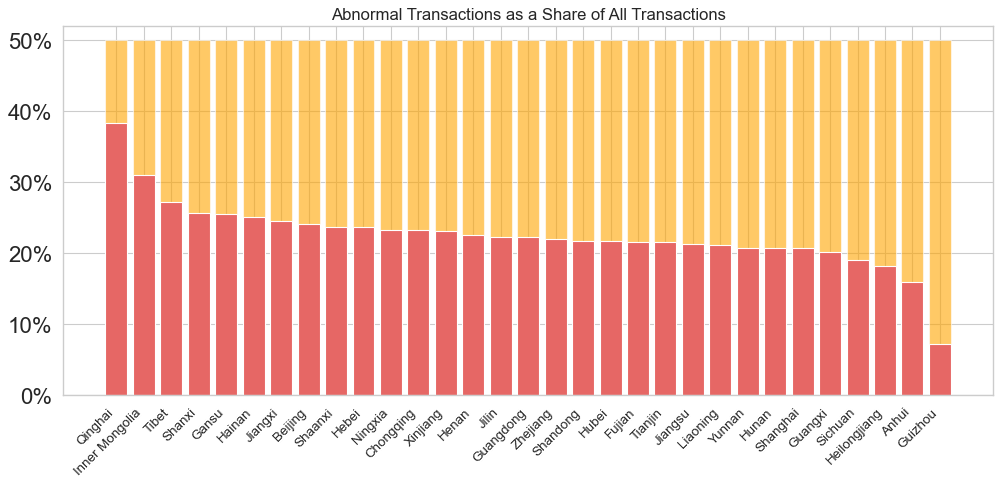

In [94]:
plt.figure(figsize=(15, 6), dpi=80)
plt.bar(province_risk.index, 0.5, color="orange", alpha=0.6)
plt.bar(province_risk.index, province_risk.values, color="#e66765", alpha=1)
plt.title("Abnormal Transactions as a Share of All Transactions", fontsize=15)
plt.ylim(0, 0.52)
plt.yticks(
    ticks=np.arange(0, 0.6, step=0.1),
    labels=["0%", "10%", "20%", "30%", "40%", "50%"],
    fontsize=20,
)
plt.xticks(range(len(province_risk)), province_risk.index, fontsize=12, rotation=45, ha="right")
plt.show()

Abnormal rates vary across provinces. Qinghai, Inner Mongolia, and Tibet are substantially higher than most regions, possibly reflecting logistics coverage or sample-size effects. Anhui, Heilongjiang, Sichuan, and Guizhou are below 20%, while most provinces lie between 20% and 25%. Because small regional samples can produce unstable rates, these values should be interpreted cautiously. The training-derived provincial abnormal rate is nevertheless a useful candidate aggregate feature.

In [95]:
train["Province"] = train["City"].map(dict(city_reference["Province"]))
test["Province"] = test["City"].map(dict(city_reference["Province"]))

In [96]:
# Check whether the feature-construction function needs adjustment.
def GroupByFeature(column,train,test,newcolumn):
    
    # Create the mapping from training data only.
    dic = dict(train.groupby(column)["Abnormal Label"].mean())
    
    # Create the new feature.
    train[newcolumn] = train[column].map(dic)
    test[newcolumn] = test[column].map(dic)
    
    return train, test

In [97]:
train, test = GroupByFeature("Province",train,test,"Province Risk Rate")

In [98]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate
0,1,4283851335,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,2,dakehu_zy,上海市,0,14,0.275173,Shanghai,0.206912
1,1,4281111595,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,2,nonscorpio,广州市,1,10,0.275173,Guangdong,0.222260
2,0,4106833871,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,2,qq-edf69d7,深圳市,1,16,0.275173,Guangdong,0.222260
3,0,4253622967,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,2,benson2570,宿迁市,0,21,0.275173,Jiangsu,0.212617
4,0,4276159555,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,2,dakehu_zy,西安市,1,16,0.275173,Shaanxi,0.236769


Confirm again that the training and test sets contain no missing values after mapping.

In [99]:
train.isnull().sum().sum()

np.int64(0)

In [100]:
test.isnull().sum().sum()

np.int64(6)

Missing values appear in the test set because a few city names are absent from the external mapping table. The number is small enough for explicit correction here. Later encoders will include a general strategy for categories that appear in test data but not in the training mapping.

In [101]:
test.isnull().sum()

Abnormal Label              0
Order ID                    0
Product Category            0
Product Attribution         0
Product ID                  0
Brand                       0
Order Amount                0
Quantity                    0
Order Channel               0
Payment Method              0
User ID                     0
City                        0
Order Minute Half           0
Order Hour                  0
Payment Method Risk Rate    0
Province                    3
Province Risk Rate          3
dtype: int64

In [102]:
test[test["Province"].isnull()]

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate
9393,1,4282946649,"Mobile, Photography & Digital",GO,1000376628,斐讯,399.0,1,Main Site,2,aiai131452,山西省其他城市,1,7,0.275173,NaN,NaN
11613,0,3809475249,"Maternal, Infant & Toys",POP,8001276188,大贸商,109.0,1,Main Site,2,guoqingas,山东省其他城市,1,10,0.275173,NaN,NaN
35611,0,4283977714,"Home, Kitchen & Small Appliances",GO,1000006426,飞利浦,299.0,1,Main Site,1,1587002842,江西省其他城市,1,13,0.000000,NaN,NaN


In [103]:
test.loc[9393, "Province"] = "Shanxi"
test.loc[11613, "Province"] = "Shandong"
test.loc[35611, "Province"] = "Jiangxi"

In [104]:
test.loc[test["Province"] == "Shanxi", "Province Risk Rate"]

140      0.256
469      0.256
503      0.256
560      0.256
605      0.256
         ...  
39180    0.256
39213    0.256
39312    0.256
39315    0.256
39327    0.256
Name: Province Risk Rate, Length: 746, dtype: float64

In [105]:
test.loc[test["Province"] == "Shandong", "Province Risk Rate"]

27       0.217832
84       0.217832
94       0.217832
103      0.217832
105      0.217832
           ...   
39270    0.217832
39286    0.217832
39287    0.217832
39288    0.217832
39358    0.217832
Name: Province Risk Rate, Length: 2528, dtype: float64

In [106]:
test.loc[test["Province"] == "Jiangxi", "Province Risk Rate"]

62       0.245702
82       0.245702
95       0.245702
149      0.245702
276      0.245702
           ...   
39033    0.245702
39086    0.245702
39147    0.245702
39148    0.245702
39258    0.245702
Name: Province Risk Rate, Length: 554, dtype: float64

In [107]:
test.loc[9393, "Province Risk Rate"] = 0.256
test.loc[11613, "Province Risk Rate"] = 0.217832
test.loc[35611, "Province Risk Rate"] = 0.245702

In [108]:
test.isnull().sum().sum()

np.int64(0)

#### Encode City and Province

Two categorical features now require encoding: City and Province.

In [109]:
def encodeCityProvince(column,train,test):
    "Encode City and Province categories."
    
    dic = {}
    feature = train.loc[:,column]
    unique_ = np.sort(feature.unique())
    for code, category in enumerate(unique_):
        dic[category] = code
        
    # Replace the source feature when required.
    train[column] = train[column].map(dic)
    
    # Transform the test set with the training-derived mapping.
    test[column] = test[column].map(dic)
    
    return train,test

In [110]:
for column in ["City","Province"]:
    train,test = encodeCityProvince(column,train,test)

In [111]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate
0,1,4283851335,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,2,dakehu_zy,5,0,14,0.275173,23,0.206912
1,1,4281111595,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,2,nonscorpio,131,1,10,0.275173,5,0.222260
2,0,4106833871,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,2,qq-edf69d7,220,1,16,0.275173,5,0.222260
3,0,4253622967,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,2,benson2570,115,0,21,0.275173,15,0.212617
4,0,4276159555,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,2,dakehu_zy,289,1,16,0.275173,21,0.236769


In [112]:
test.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate
0,1,4276537082,"TV, Refrigeration, Laundry & AC",POP,8001992420,樱花,19900.0,100,Main Site,2,qq-3be293b,204.0,0,14,0.275173,3,0.215807
1,0,3977175284,"Mobile, Photography & Digital",POP,8002237611,伊斯贝,990.0,100,Main Site,2,swt6263122,101.0,0,23,0.275173,3,0.215807
2,0,4245023523,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,2,nonscorpio,131.0,1,10,0.275173,5,0.222260
3,0,4284515355,"Home, Kitchen & Small Appliances",POP,8001873245,佳星,21450.0,50,Main Site,2,1382227461,131.0,1,15,0.275173,5,0.222260
4,0,4284735147,Household Essentials,POP,8002202146,奕辰,1950.0,50,Main Site,2,sagggff,95.0,0,17,0.275173,26,0.215111


In [113]:
test.isnull().sum()

Abnormal Label              0
Order ID                    0
Product Category            0
Product Attribution         0
Product ID                  0
Brand                       0
Order Amount                0
Quantity                    0
Order Channel               0
Payment Method              0
User ID                     0
City                        3
Order Minute Half           0
Order Hour                  0
Payment Method Risk Rate    0
Province                    0
Province Risk Rate          0
dtype: int64

A few unseen cities again produce missing codes. Because the count is very small, they are assigned an explicit fallback code.

In [114]:
test["City"].value_counts()

City
50.0     4066
5.0      1996
131.0    1786
220.0    1577
95.0     1005
         ... 
245.0       1
224.0       1
261.0       1
28.0        1
41.0        1
Name: count, Length: 349, dtype: int64

In [115]:
test.loc[test["City"].isnull(),"City"] = 350

#### Save the Updated Data

In [116]:
train.to_csv("data/train_en.csv", index=False)
test.to_csv("data/test_en.csv", index=False)

#### Interpretation: Provincial Abnormal Rates

The highest training-set provincial rates are observed in Qinghai, Inner Mongolia, Tibet, Shanxi, and Gansu. Provincial differences can reflect both genuine business effects—channel coverage, logistics risk, or regional fraud patterns—and sampling effects, because means from small provinces are unstable.

In production, this type of target-derived feature is commonly stabilized with smoothing, Bayesian shrinkage, or a minimum-sample threshold.

### 3.4 Product and Channel Features: Category-Risk and Basic Encoding

In [117]:
#train = pd.read_csv(r'data/train_en.csv',index_col=0)
#test = pd.read_csv(r'data/test_en.csv',index_col=0)

If a product or category has unusually high return, dispute, or abuse risk, its orders should also have a higher abnormal rate. High-risk products can therefore be marked explicitly. The same logic applies to Order Channel and Product Attribution.

Begin with Product Category by comparing its abnormal rate across categories.

In [118]:
train.groupby("Product Category")["Abnormal Label"].mean()

Product Category
Apparel & Footwear                  0.276811
Automotive Products                 0.229976
Bags & Luxury Goods                 0.349172
Beauty & Personal Care              0.148900
Books & Audiovisual                 0.284768
Computers, Office & Printing        0.215029
Food & Beverages                    0.199508
Furniture & Building Materials      0.262840
Health & Medical                    0.233255
Home Textiles & Bedding             0.173088
Home, Kitchen & Small Appliances    0.193856
Household Essentials                0.235079
Maternal, Infant & Toys             0.173181
Mobile, Photography & Digital       0.261565
Sports & Outdoors                   0.234420
TV, Refrigeration, Laundry & AC     0.201848
Watches & Jewelry                   0.343860
Name: Abnormal Label, dtype: float64

In [119]:
category_risk = train.groupby("Product Category")["Abnormal Label"].mean()

In [120]:
category_risk = category_risk.sort_values()

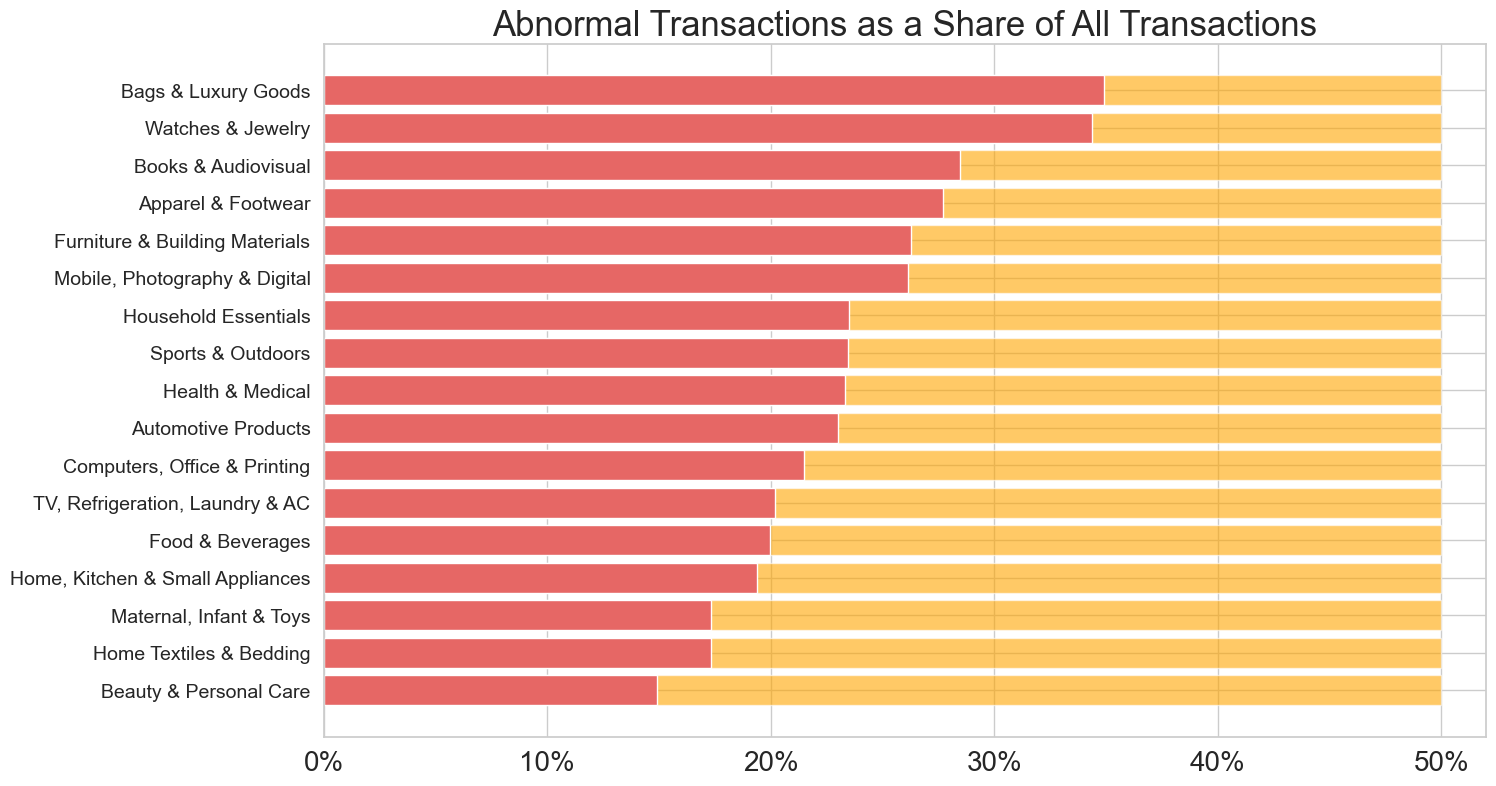

In [121]:
plt.figure(figsize=(15, 9), dpi=100)
plt.barh(category_risk.index, 0.5, color="orange", alpha=0.6)
plt.barh(category_risk.index, category_risk.values, color="#e66765", alpha=1)
plt.title("Abnormal Transactions as a Share of All Transactions", fontsize=25)
plt.xlim(0, 0.52)
plt.xticks(
    ticks=np.linspace(0, 0.5, num=6),
    labels=["0%", "10%", "20%", "30%", "40%", "50%"],
    fontsize=20,
)
plt.yticks(range(len(category_risk)), category_risk.index, fontsize=14)
plt.show()

Watches and jewelry, luxury bags, and books/audio-visual products have the highest observed rates, while home textiles, maternal-and-infant products, and beauty products are lower. No category is overwhelmingly riskier than all others. The rate still quantifies category-level transaction risk and is therefore added as an aggregate feature.

In [122]:
train.groupby("Order Channel")["Abnormal Label"].mean().sort_values(ascending=False)

Order Channel
Mobile Group Buying    0.501931
Flash Sale             0.400281
Mobile Flash Sale      0.339863
Group Buying           0.330159
Mobile Site            0.287742
Dangdang               0.209125
Main Site              0.167849
do.site_id             0.097698
Name: Abnormal Label, dtype: float64

In [123]:
channel_risk = (
    train.groupby("Order Channel")["Abnormal Label"].mean().sort_values()
)

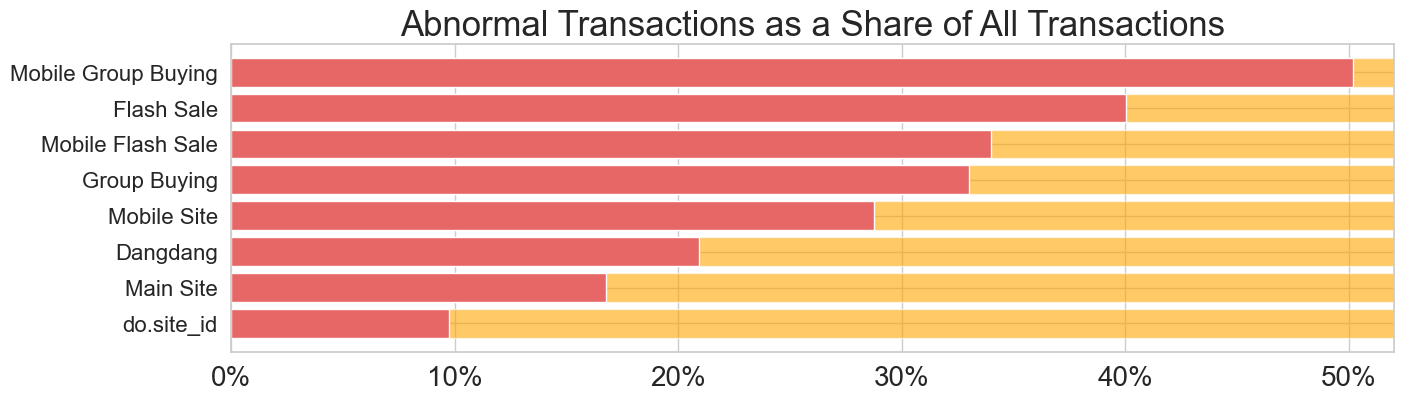

In [124]:
plt.figure(figsize=(15, 4), dpi=100)
plt.barh(channel_risk.index, 1, color="orange", alpha=0.6)
plt.barh(channel_risk.index, channel_risk.values, color="#e66765", alpha=1)
plt.title("Abnormal Transactions as a Share of All Transactions", fontsize=25)
plt.xlim(0, 0.52)
plt.xticks(
    ticks=np.linspace(0, 0.5, num=6),
    labels=["0%", "10%", "20%", "30%", "40%", "50%"],
    fontsize=20,
)
plt.yticks(range(len(channel_risk)), channel_risk.index, fontsize=16)
plt.show()

Group-buying and flash-sale channels show relatively high abnormal rates. Mobile channels also appear riskier than desktop channels.

In [125]:
train.groupby("Product Attribution")["Abnormal Label"].mean().sort_values(ascending=False)

Product Attribution
POP    0.294727
GO     0.178732
Name: Abnormal Label, dtype: float64

Within Product Attribution, third-party POP stores have a higher abnormal rate than the platform's GO direct-retail channel.

#### Add Aggregate Risk Features

In [126]:
risk_features = {
    "Product Category": "Product Category Risk Rate",
    "Product Attribution": "Product Attribution Risk Rate",
    "Order Channel": "Order Channel Risk Rate",
}
for source_column, risk_column in risk_features.items():
    train, test = GroupByFeature(source_column, train, test, risk_column)

In [127]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate
0,1,4283851335,"Mobile, Photography & Digital",POP,8002042497,三星,766000.0,200,Main Site,2,dakehu_zy,5,0,14,0.275173,23,0.206912,0.261565,0.294727,0.167849
1,1,4281111595,Furniture & Building Materials,POP,8002199518,纬度空间,100.0,100,Main Site,2,nonscorpio,131,1,10,0.275173,5,0.222260,0.262840,0.294727,0.167849
2,0,4106833871,Household Essentials,POP,8002212182,品道天元,8800.0,100,Main Site,2,qq-edf69d7,220,1,16,0.275173,5,0.222260,0.235079,0.294727,0.167849
3,0,4253622967,"Computers, Office & Printing",POP,8001748897,清华同方,880.0,100,Main Site,2,benson2570,115,0,21,0.275173,15,0.212617,0.215029,0.294727,0.167849
4,0,4276159555,Household Essentials,GO,1000341307,乐扣乐扣,4900.0,100,Main Site,2,dakehu_zy,289,1,16,0.275173,21,0.236769,0.235079,0.178732,0.167849


#### Encode the Original Categories

In [128]:
def EasyEncode(column,train,test):
    "Encode City and Province categories."
    
    dic = {}
    feature = train.loc[:,column]
    unique_ = np.sort(feature.unique())
    for code, category in enumerate(unique_):
        dic[category] = code
        
    # Replace the source feature when required.
    train[column] = train[column].map(dic)
    
    # Transform the test set with the training-derived mapping.
    test[column] = test[column].map(dic)
    
    return train,test

In [129]:
for i in ["Product Category","Product Attribution","Order Channel"]:
    train,test = EasyEncode(i,train,test)

In [130]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate
0,1,4283851335,13,1,8002042497,三星,766000.0,200,3,2,dakehu_zy,5,0,14,0.275173,23,0.206912,0.261565,0.294727,0.167849
1,1,4281111595,7,1,8002199518,纬度空间,100.0,100,3,2,nonscorpio,131,1,10,0.275173,5,0.222260,0.262840,0.294727,0.167849
2,0,4106833871,11,1,8002212182,品道天元,8800.0,100,3,2,qq-edf69d7,220,1,16,0.275173,5,0.222260,0.235079,0.294727,0.167849
3,0,4253622967,5,1,8001748897,清华同方,880.0,100,3,2,benson2570,115,0,21,0.275173,15,0.212617,0.215029,0.294727,0.167849
4,0,4276159555,11,0,1000341307,乐扣乐扣,4900.0,100,3,2,dakehu_zy,289,1,16,0.275173,21,0.236769,0.235079,0.178732,0.167849


#### Save the Updated Data

In [131]:
train.to_csv("data/train_en.csv", index=False)
test.to_csv("data/test_en.csv", index=False)

#### Interpretation: Channel and Store-Type Risk

Strong-promotion channels such as mobile group buying and flash sales have higher abnormal rates, which is consistent with promotion abuse, fabricated transactions, and malicious arbitrage concentrating in subsidized channels. POP stores are also riskier than the GO direct-retail channel, consistent with the greater governance difficulty of third-party marketplaces.

### 3.5 High-Cardinality Features: User ID, Product ID, and Brand

In [132]:
#train = pd.read_csv(r'data/train_en.csv',index_col=0)
#test = pd.read_csv(r'data/test_en.csv',index_col=0)

User ID, Product ID, and Brand are unusual categorical features. IDs are often dropped because they are nearly unique, but they may still be informative here: an order can be abnormal because it involves a risky user, product, or brand. These fields share an important difficulty.

#### Some IDs or brands have only one observation

Product categories and cities generally contain many transactions, so their rates are based on repeated observations. A product, brand, or user may appear only once in the year, making its observed label unsuitable as a risk estimate.

The categories are therefore divided into:

> 1. Categories with too little history for reliable risk estimation.
> 2. Categories with sufficient volume for an abnormal-rate estimate.

Low-history categories receive a special value, while sufficiently frequent categories receive a training-derived abnormal rate.

#### These Fields Have Far More Categories Than Ordinary Categorical Features

For low-cardinality fields such as City or Product Category, most categories appear in both training and test data. With high-cardinality IDs and brands, the test set inevitably contains categories never observed in training. A reusable encoder must assign codes to these unseen values without introducing missing data.

In [133]:
for i in ["Product Category","City","User ID","Product ID","Brand"]:
    cate = len(train[i].unique())
    print(i,cate)

Product Category 17
City 362
User ID 58488
Product ID 17252
Brand 2507


In [134]:
train.shape[0]

91868

In [135]:
test.shape[0]

39414

These two issues make the three fields harder to process than ordinary categorical variables. Begin by analyzing their abnormal rates.

#### User ID

From a business perspective, user-level abnormal rates should be polarized: many users have no abnormal orders, a small number are consistently high risk, and fewer users fall in the middle. A reliably high historical rate can therefore signal a risky user.

In [136]:
# How many unique users placed orders?
len(train["User ID"].unique())

58488

In [137]:
# How many users placed only one order?
(train.groupby(["User ID"])["Abnormal Label"].count() == 1).sum()

np.int64(44137)

Most users placed only one order, so their personal abnormal rate cannot be estimated reliably. These users receive a User Risk Rate of `-1`, explicitly distinguishing insufficient-history users from users with an estimated rate.

In [138]:
# Estimate risk only for users with more than one order.
MultipleBuyRatio = train.groupby(["User ID"])["Abnormal Label"].mean()[train.groupby(["User ID"])["Abnormal Label"].count() != 1].sort_values()

In [139]:
# More than half of repeat users have no abnormal orders.

In [140]:
MultipleBuyRatio.describe([0.6,0.7,0.8,0.9,0.99])

count    14351.000000
mean         0.258921
std          0.347363
min          0.000000
50%          0.000000
60%          0.250000
70%          0.500000
80%          0.500000
90%          1.000000
99%          1.000000
max          1.000000
Name: Abnormal Label, dtype: float64

#### Product ID

Product volume cannot be inferred from transaction-row count alone because one row may contain multiple units. Total Quantity is therefore used to measure product sales volume.

In [141]:
train.groupby(["Product ID"])["Quantity"].sum().describe()

count    17252.000000
mean         6.321528
std         37.765090
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       2606.000000
Name: Quantity, dtype: float64

Average product volume is only about 6.32 units. Products with fewer than 10 units sold are treated as having insufficient history; abnormal rates are calculated only for products with at least 10 units.

In [142]:
ProductIDRatio = train.groupby(["Product ID"])["Abnormal Label"].mean()[train.groupby(["Product ID"])["Quantity"].sum() >=10]

In [143]:
ProductIDRatio.describe() # Most rates are below 30%, consistent with business expectations.

count    1748.000000
mean        0.229465
std         0.208118
min         0.000000
25%         0.083333
50%         0.176471
75%         0.324169
max         1.000000
Name: Abnormal Label, dtype: float64

#### Brand

As with Product ID, total Quantity is used to assess brand-level transaction volume.

In [144]:
train.groupby(["Brand"])["Quantity"].sum().describe()

count    2507.000000
mean       43.501795
std       197.462143
min         1.000000
25%         2.000000
50%         5.000000
75%        18.000000
max      3904.000000
Name: Quantity, dtype: float64

The mean brand volume is approximately 43 units, so many brands have adequate history. Brands with fewer than 10 units are treated as insufficient-history categories; rates are calculated for brands with at least 10 units.

In [145]:
BrandIDRatio = train.groupby(["Brand"])["Abnormal Label"].mean()[train.groupby(["Brand"])["Quantity"].sum() >=10]

In [146]:
BrandIDRatio.describe() # Most rates are below 30%, consistent with business expectations.

count    882.000000
mean       0.246267
std        0.167831
min        0.000000
25%        0.133333
50%        0.217391
75%        0.333333
max        1.000000
Name: Abnormal Label, dtype: float64

User Risk Rate, Product Risk Rate, and Brand Risk Rate are added as aggregate features. Training categories with insufficient history receive `-1`; sufficiently frequent categories receive their abnormal rate. Test categories use the training-derived value when available and `-1` otherwise.

In [147]:
# First create a category-to-risk mapping.

In [148]:
df = pd.DataFrame(index=train["User ID"].unique())
df["User Risk Rate"] = -1.0

In [149]:
df.head()

,User Risk Rate
dakehu_zy,-1
nonscorpio,-1
qq-edf69d7,-1
benson2570,-1
qq-3be293b,-1


In [150]:
df.shape

(58488, 1)

In [151]:
df.loc[MultipleBuyRatio.index,"User Risk Rate"] = MultipleBuyRatio

In [152]:
dict(df["User Risk Rate"])

{'dakehu_zy': np.float64(0.13333333333333333),
 'nonscorpio': np.float64(0.3333333333333333),
 'qq-edf69d7': np.float64(0.0),
 'benson2570': np.float64(-1.0),
 'qq-3be293b': np.float64(-1.0),
 'saabnan': np.float64(0.25),
 'tmall-4497': np.float64(0.0),
 'gailiju_cx': np.float64(-1.0),
 'dsjalfdsaj': np.float64(0.0),
 '499091968_': np.float64(0.0),
 'qq-5dc6b31': np.float64(1.0),
 'xdlkliukai': np.float64(-1.0),
 'fsdaggfdsg': np.float64(-1.0),
 'cwergdsg': np.float64(-1.0),
 'twodaya': np.float64(-1.0),
 'tmall-3604': np.float64(-1.0),
 'tmall-7432': np.float64(-1.0),
 '415103410_': np.float64(-1.0),
 'chwan1': np.float64(-1.0),
 'yymmxxyy': np.float64(1.0),
 'lws0898': np.float64(-1.0),
 '1533857591': np.float64(0.0),
 'you123you1': np.float64(0.6666666666666666),
 'lidongli01': np.float64(0.6),
 'ernino_dil': np.float64(1.0),
 'tmall-1097': np.float64(-1.0),
 'wjxjx': np.float64(0.0),
 '1304654666': np.float64(0.0),
 '1354918398': np.float64(0.07692307692307693),
 'tengguangy': np.f

In [153]:
# Map the dictionary to the new feature.

In [154]:
train["User Risk Rate"] = train["User ID"].map(dict(df["User Risk Rate"]))

In [155]:
train["User Risk Rate"].head()

0    0.133333
1    0.333333
2    0.000000
3   -1.000000
4    0.133333
Name: User Risk Rate, dtype: float64

In [156]:
# Check whether each test user appeared in training.

In [157]:
dic = {}
for i in test["User ID"]:
    if i in MultipleBuyRatio.index:
        dic[i] = MultipleBuyRatio[i]
    else:
        dic[i] = -1

In [158]:
test["User Risk Rate"] = test["User ID"].map(dic)

In [159]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate
0,1,4283851335,13,1,8002042497,三星,766000.0,200,3,2,...,5,0,14,0.275173,23,0.206912,0.261565,0.294727,0.167849,0.133333
1,1,4281111595,7,1,8002199518,纬度空间,100.0,100,3,2,...,131,1,10,0.275173,5,0.222260,0.262840,0.294727,0.167849,0.333333
2,0,4106833871,11,1,8002212182,品道天元,8800.0,100,3,2,...,220,1,16,0.275173,5,0.222260,0.235079,0.294727,0.167849,0.000000
3,0,4253622967,5,1,8001748897,清华同方,880.0,100,3,2,...,115,0,21,0.275173,15,0.212617,0.215029,0.294727,0.167849,-1.000000
4,0,4276159555,11,0,1000341307,乐扣乐扣,4900.0,100,3,2,...,289,1,16,0.275173,21,0.236769,0.235079,0.178732,0.167849,0.133333


In [160]:
test.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,City,Order Minute Half,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate
0,1,4276537082,15,1,8001992420,樱花,19900.0,100,3,2,...,204.0,0,14,0.275173,3,0.215807,0.201848,0.294727,0.167849,-1.000000
1,0,3977175284,13,1,8002237611,伊斯贝,990.0,100,3,2,...,101.0,0,23,0.275173,3,0.215807,0.261565,0.294727,0.167849,-1.000000
2,0,4245023523,7,1,8002199518,纬度空间,100.0,100,3,2,...,131.0,1,10,0.275173,5,0.222260,0.262840,0.294727,0.167849,0.333333
3,0,4284515355,10,1,8001873245,佳星,21450.0,50,3,2,...,131.0,1,15,0.275173,5,0.222260,0.193856,0.294727,0.167849,-1.000000
4,0,4284735147,11,1,8002202146,奕辰,1950.0,50,3,2,...,95.0,0,17,0.275173,26,0.215111,0.235079,0.294727,0.167849,-1.000000


Package the preceding workflow into a reusable function.

In [161]:
def GroupByFeature2(column, train, test, newcolumn, ratio):
    # Create a floating-point mapping so fractional risk rates remain type-safe.
    df = pd.DataFrame(index=train[column].unique())
    df[newcolumn] = -1.0
    df.loc[ratio.index, newcolumn] = ratio

    # Map values to the training set.
    train[newcolumn] = train[column].map(dict(df[newcolumn]))

    # Check whether test categories appeared in training.
    mapping = {}
    for category in test[column]:
        if category in ratio.index:
            mapping[category] = ratio[category]
        else:
            mapping[category] = -1.0

    # Map values to the test set.
    test[newcolumn] = test[column].map(mapping)
    return train, test

In [162]:
train,test = GroupByFeature2("Product ID",train,test,"Product Risk Rate",ProductIDRatio)
train,test = GroupByFeature2("Brand",train,test,"Brand Risk Rate",BrandIDRatio)

In [163]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate
0,1,4283851335,13,1,8002042497,三星,766000.0,200,3,2,...,14,0.275173,23,0.206912,0.261565,0.294727,0.167849,0.133333,1.000000,0.340804
1,1,4281111595,7,1,8002199518,纬度空间,100.0,100,3,2,...,10,0.275173,5,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000
2,0,4106833871,11,1,8002212182,品道天元,8800.0,100,3,2,...,16,0.275173,5,0.222260,0.235079,0.294727,0.167849,0.000000,0.238462,0.286842
3,0,4253622967,5,1,8001748897,清华同方,880.0,100,3,2,...,21,0.275173,15,0.212617,0.215029,0.294727,0.167849,-1.000000,0.296296,0.298387
4,0,4276159555,11,0,1000341307,乐扣乐扣,4900.0,100,3,2,...,16,0.275173,21,0.236769,0.235079,0.178732,0.167849,0.133333,0.119565,0.179739


#### Encode the High-Cardinality Categories

Training and test data must again be encoded separately. Categories found in training use the training code. Categories that appear only in test data receive new codes after the training code range, preventing missing values while keeping training codes unchanged.

In [164]:
def ComplexEncode(column,train,test):
    "Encode categories with unseen-value handling."
    
    dic = {}
    feature = train.loc[:,column]
    unique_ = np.sort(feature.unique())
    for code, category in enumerate(unique_):
        dic[category] = code
        
    # Replace the source feature when required.
    train[column] = train[column].map(dic)
    
    # Transform the test set.
    nullcheck = test[column].map(dic)
    while nullcheck.isnull().sum() > 0:
        print("A test category was not observed in training.")
        newcategory = test.loc[nullcheck.isnull(),column].unique()
        for i in newcategory:
            dic[i] = len(dic)
        nullcheck = test[column].map(dic)
    test[column] = nullcheck
    
    return train,test

In [165]:
for column in ["User ID","Product ID","Brand"]:
    train,test = ComplexEncode(column,train,test)

A test category was not observed in training.
A test category was not observed in training.
A test category was not observed in training.


In [166]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate
0,1,4283851335,13,1,13080,199,766000.0,200,3,2,...,14,0.275173,23,0.206912,0.261565,0.294727,0.167849,0.133333,1.000000,0.340804
1,1,4281111595,7,1,15075,1856,100.0,100,3,2,...,10,0.275173,5,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000
2,0,4106833871,11,1,15212,676,8800.0,100,3,2,...,16,0.275173,5,0.222260,0.235079,0.294727,0.167849,0.000000,0.238462,0.286842
3,0,4253622967,5,1,11454,1568,880.0,100,3,2,...,21,0.275173,15,0.212617,0.215029,0.294727,0.167849,-1.000000,0.296296,0.298387
4,0,4276159555,11,0,4800,262,4900.0,100,3,2,...,16,0.275173,21,0.236769,0.235079,0.178732,0.167849,0.133333,0.119565,0.179739


In [167]:
test.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Order Hour,Payment Method Risk Rate,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate
0,1,4276537082,15,1,12689,1406,19900.0,100,3,2,...,14,0.275173,3,0.215807,0.201848,0.294727,0.167849,-1.000000,0.000000,0.083333
1,0,3977175284,13,1,15601,339,990.0,100,3,2,...,23,0.275173,3,0.215807,0.261565,0.294727,0.167849,-1.000000,0.153846,0.372263
2,0,4245023523,7,1,15075,1856,100.0,100,3,2,...,10,0.275173,5,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000
3,0,4284515355,10,1,17252,393,21450.0,50,3,2,...,15,0.275173,5,0.222260,0.193856,0.294727,0.167849,-1.000000,-1.000000,0.162162
4,0,4284735147,11,1,15111,797,1950.0,50,3,2,...,17,0.275173,26,0.215111,0.235079,0.294727,0.167849,-1.000000,0.248485,0.240741


Confirm that the encoded test fields contain no missing values.

In [168]:
test["User ID"].isnull().sum()

np.int64(0)

In [169]:
test["Product ID"].isnull().sum()

np.int64(0)

In [170]:
test["Brand"].isnull().sum()

np.int64(0)

#### Save the Training and Test Sets

In [171]:
train.to_csv("data/train_en.csv", index=False)
test.to_csv("data/test_en.csv", index=False)

#### Interpretation: Why High-Cardinality Encoding Requires Care

The multi-order user distribution has a median abnormal rate of zero, while the upper quantiles approach one. Historical risk features can therefore be highly informative, but sparse histories make them prone to overfitting. Minimum-order and minimum-volume thresholds—such as the `>= 10` rule used for products and brands—are a common stabilization technique.

### 3.6 Continuous Features: Order Amount and Quantity

In [172]:
#train = pd.read_csv(r'data/train_en.csv',index_col=0)
#test = pd.read_csv(r'data/test_en.csv',index_col=0)

In B2C, platform-to-consumer, and C2C commerce, most transactions involve individual customers. Extremely large amounts or quantities may therefore indicate elevated risk. Compare the Order Amount distributions of normal and abnormal transactions to determine whether high-value orders are more likely to be labeled abnormal.

In [173]:
# Compare mean amounts: abnormal transactions have a higher average.
train.groupby(["Abnormal Label"])["Order Amount"].mean()

Abnormal Label
0    606.823929
1    902.707100
Name: Order Amount, dtype: float64

In [174]:
abnormal = train.loc[train["Abnormal Label"] == 1, "Order Amount"]
normal = train.loc[train["Abnormal Label"] != 1, "Order Amount"]

In [175]:
abnormal.describe()

count     19915.000000
mean        902.707100
std        5790.468611
min           0.500000
25%          49.000000
50%         118.000000
75%         688.000000
max      766000.000000
Name: Order Amount, dtype: float64

In [176]:
normal.describe()

count     71953.000000
mean        606.823929
std        2160.500859
min           0.500000
25%          21.900000
50%          89.900000
75%         338.000000
max      383000.000000
Name: Order Amount, dtype: float64

Abnormal transactions have both a higher mean amount and greater variance. Density plots provide a clearer view of the distributions.

In [177]:
import seaborn as sns

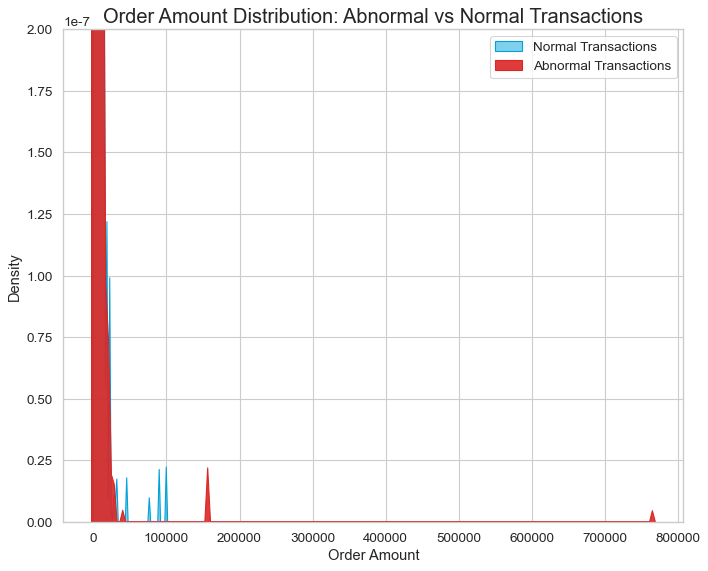

In [178]:
plt.figure(figsize=(10, 8), dpi=80)
sns.kdeplot(normal, fill=True, color="#01a2d9", label="Normal Transactions", alpha=0.5)
sns.kdeplot(abnormal, fill=True, color="#dc2624", label="Abnormal Transactions", alpha=0.9)
plt.title("Order Amount Distribution: Abnormal vs Normal Transactions", fontsize=18)
plt.ylim((0, 0.0000002))
plt.legend()
plt.show()

Abnormal transactions have a long right tail, while normal transactions show a small concentration near 380,000. In this sample, transactions above 400,000 are all abnormal. Below roughly 380,000, the two distributions overlap heavily. Order Amount is therefore discretized, allowing risk patterns to be compared across value ranges and supporting additional bin-level features.

In [179]:
from sklearn.preprocessing import KBinsDiscretizer as KBD

In [180]:
enc = KBD(n_bins=10,encode="ordinal",strategy = 'kmeans')

In [181]:
enc = enc.fit(pd.DataFrame(train["Order Amount"]))

In [182]:
train["Amount Bin"] = enc.transform(pd.DataFrame(train["Order Amount"]))

In [183]:
train.groupby(["Amount Bin"])["Order Amount"].min()

Amount Bin
0.0         0.5
1.0      1128.0
2.0      3240.0
3.0      6866.0
4.0     13189.0
5.0     25790.0
6.0     71980.0
7.0    155999.0
8.0    383000.0
9.0    766000.0
Name: Order Amount, dtype: float64

In [184]:
train.groupby(["Amount Bin"])["Order Amount"].max()

Amount Bin
0.0      1120.0
1.0      3226.0
2.0      6799.0
3.0     12999.0
4.0     23998.0
5.0     45490.0
6.0     99840.0
7.0    155999.0
8.0    383000.0
9.0    766000.0
Name: Order Amount, dtype: float64

In [185]:
df = pd.DataFrame(index=train.groupby(["Amount Bin"])["Order Amount"].max().index)

df["Lower Bound"] = train.groupby(["Amount Bin"])["Order Amount"].min()
df["Upper Bound"] = train.groupby(["Amount Bin"])["Order Amount"].max()

In [186]:
df # Extreme bins may contain isolated values because of the long tail.

,Lower Bound,Upper Bound
Amount Bin,,
0.0,0.5,1120.0
1.0,1128.0,3226.0
2.0,3240.0,6799.0
3.0,6866.0,12999.0
4.0,13189.0,23998.0
5.0,25790.0,45490.0
6.0,71980.0,99840.0
7.0,155999.0,155999.0
8.0,383000.0,383000.0


In [187]:
train.groupby(["Amount Bin"])["Order Amount"].mean()

Amount Bin
0.0       155.338904
1.0      2088.598132
2.0      4363.434501
3.0      9276.086888
4.0     16872.602041
5.0     32339.400000
6.0     85476.666667
7.0    155999.000000
8.0    383000.000000
9.0    766000.000000
Name: Order Amount, dtype: float64

Apply the fitted amount-bin transformation to both training and test data.

In [188]:
train["Amount Bin"] = enc.transform(pd.DataFrame(train["Order Amount"]))
test["Amount Bin"] = enc.transform(pd.DataFrame(test["Order Amount"]))

Also map the training-set mean amount of each bin into both datasets.

In [189]:
dic = dict(train.groupby(["Amount Bin"])["Order Amount"].mean())

train["Bin Mean"] = train["Amount Bin"].map(dic)
test["Bin Mean"] = test["Amount Bin"].map(dic)

In [190]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate,Amount Bin,Bin Mean
0,1,4283851335,13,1,13080,199,766000.0,200,3,2,...,23,0.206912,0.261565,0.294727,0.167849,0.133333,1.000000,0.340804,9.0,766000.000000
1,1,4281111595,7,1,15075,1856,100.0,100,3,2,...,5,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000,0.0,155.338904
2,0,4106833871,11,1,15212,676,8800.0,100,3,2,...,5,0.222260,0.235079,0.294727,0.167849,0.000000,0.238462,0.286842,3.0,9276.086888
3,0,4253622967,5,1,11454,1568,880.0,100,3,2,...,15,0.212617,0.215029,0.294727,0.167849,-1.000000,0.296296,0.298387,0.0,155.338904
4,0,4276159555,11,0,4800,262,4900.0,100,3,2,...,21,0.236769,0.235079,0.178732,0.167849,0.133333,0.119565,0.179739,2.0,4363.434501


In [191]:
test.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Province,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate,Amount Bin,Bin Mean
0,1,4276537082,15,1,12689,1406,19900.0,100,3,2,...,3,0.215807,0.201848,0.294727,0.167849,-1.000000,0.000000,0.083333,4.0,16872.602041
1,0,3977175284,13,1,15601,339,990.0,100,3,2,...,3,0.215807,0.261565,0.294727,0.167849,-1.000000,0.153846,0.372263,0.0,155.338904
2,0,4245023523,7,1,15075,1856,100.0,100,3,2,...,5,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000,0.0,155.338904
3,0,4284515355,10,1,17252,393,21450.0,50,3,2,...,5,0.222260,0.193856,0.294727,0.167849,-1.000000,-1.000000,0.162162,4.0,16872.602041
4,0,4284735147,11,1,15111,797,1950.0,50,3,2,...,26,0.215111,0.235079,0.294727,0.167849,-1.000000,0.248485,0.240741,1.0,2088.598132


Apply similar reasoning to Quantity.

In [192]:
abnormal = train.loc[train["Abnormal Label"] == 1, "Quantity"]
normal = train.loc[train["Abnormal Label"] != 1, "Quantity"]

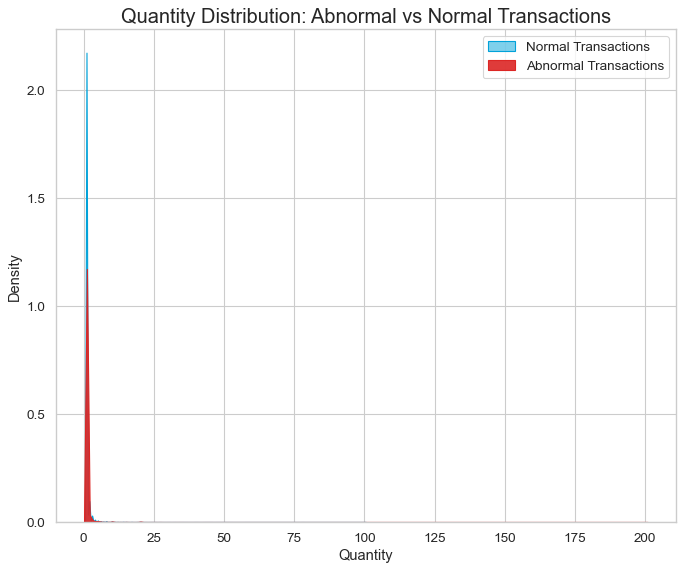

In [193]:
plt.figure(figsize=(10, 8), dpi=80)
sns.kdeplot(normal, fill=True, color="#01a2d9", label="Normal Transactions", alpha=0.5)
sns.kdeplot(abnormal, fill=True, color="#dc2624", label="Abnormal Transactions", alpha=0.9)
plt.title("Quantity Distribution: Abnormal vs Normal Transactions", fontsize=18)
plt.legend()
plt.show()

Transactions containing more than about 20 items are predominantly abnormal, while the distributions overlap strongly below that level. In both classes, 99% of rows contain fewer than five units. Quantity may therefore contribute little over most of its range. A simple binary feature is created: quantities above 25 are marked as high risk (`1`), and all others as lower risk (`0`).

In [194]:
train["Quantity Risk Flag"] = 0
test["Quantity Risk Flag"] = 0
train.loc[train["Quantity"] > 25,"Quantity Risk Flag"] = 1
test.loc[test["Quantity"] > 25,"Quantity Risk Flag"] = 1

In [195]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate,Amount Bin,Bin Mean,Quantity Risk Flag
0,1,4283851335,13,1,13080,199,766000.0,200,3,2,...,0.206912,0.261565,0.294727,0.167849,0.133333,1.000000,0.340804,9.0,766000.000000,1
1,1,4281111595,7,1,15075,1856,100.0,100,3,2,...,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000,0.0,155.338904,1
2,0,4106833871,11,1,15212,676,8800.0,100,3,2,...,0.222260,0.235079,0.294727,0.167849,0.000000,0.238462,0.286842,3.0,9276.086888,1
3,0,4253622967,5,1,11454,1568,880.0,100,3,2,...,0.212617,0.215029,0.294727,0.167849,-1.000000,0.296296,0.298387,0.0,155.338904,1
4,0,4276159555,11,0,4800,262,4900.0,100,3,2,...,0.236769,0.235079,0.178732,0.167849,0.133333,0.119565,0.179739,2.0,4363.434501,1


#### Save the Fully Engineered Data

In [196]:
train.to_csv("data/train_en.csv", index=False)
test.to_csv("data/test_en.csv", index=False)

Feature engineering and preprocessing are now complete. The next section begins model construction and tuning.

#### Interpretation: Long-Tailed Amount and Quantity Distributions

- Order Amount is strongly long-tailed, so its mean and variance do not adequately describe the main body of the distribution.
- Tree models can use the raw amount directly, but interval-level risk can be more stable and interpretable in anomaly detection.
- `KBinsDiscretizer(strategy='kmeans')` produces data-adaptive bins. In a long-tailed distribution, some extreme bins may contain very few distinct values, so bin counts should be monitored.
- A useful extension would be a smoothed, training-only abnormal rate for each amount bin.
- Quantity is also long-tailed; the binary high-quantity indicator reduces the influence of extreme values.

## 4. Model Building, Tuning, and Fusion

This section converts the engineered features into predictive models:

- Compare Random Forest, GBDT, and XGBoost.
- Tune AUC through class weighting, tree count, learning rate, and overfitting controls.
- Combine the tuned models with soft voting.

In [197]:
#!pip install xgboost

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
N_JOBS = 4

In [199]:
train = pd.read_csv("data/train_en.csv")
test = pd.read_csv("data/test_en.csv")

In [200]:
train.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate,Amount Bin,Bin Mean,Quantity Risk Flag
0,1,4283851335,13,1,13080,199,766000.0,200,3,2,...,0.206912,0.261565,0.294727,0.167849,0.133333,1.000000,0.340804,9.0,766000.000000,1
1,1,4281111595,7,1,15075,1856,100.0,100,3,2,...,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000,0.0,155.338904,1
2,0,4106833871,11,1,15212,676,8800.0,100,3,2,...,0.222260,0.235079,0.294727,0.167849,0.000000,0.238462,0.286842,3.0,9276.086888,1
3,0,4253622967,5,1,11454,1568,880.0,100,3,2,...,0.212617,0.215029,0.294727,0.167849,-1.000000,0.296296,0.298387,0.0,155.338904,1
4,0,4276159555,11,0,4800,262,4900.0,100,3,2,...,0.236769,0.235079,0.178732,0.167849,0.133333,0.119565,0.179739,2.0,4363.434501,1


In [201]:
test.head()

,Abnormal Label,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,...,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate,Amount Bin,Bin Mean,Quantity Risk Flag
0,1,4276537082,15,1,12689,1406,19900.0,100,3,2,...,0.215807,0.201848,0.294727,0.167849,-1.000000,0.000000,0.083333,4.0,16872.602041,1
1,0,3977175284,13,1,15601,339,990.0,100,3,2,...,0.215807,0.261565,0.294727,0.167849,-1.000000,0.153846,0.372263,0.0,155.338904,1
2,0,4245023523,7,1,15075,1856,100.0,100,3,2,...,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000,0.0,155.338904,1
3,0,4284515355,10,1,17252,393,21450.0,50,3,2,...,0.222260,0.193856,0.294727,0.167849,-1.000000,-1.000000,0.162162,4.0,16872.602041,1
4,0,4284735147,11,1,15111,797,1950.0,50,3,2,...,0.215111,0.235079,0.294727,0.167849,-1.000000,0.248485,0.240741,1.0,2088.598132,1


In [202]:
Xtrain = train.iloc[:,1:]
Xtest = test.iloc[:,1:]
Ytrain = train.iloc[:,0]
Ytest = test.iloc[:,0]

In [203]:
Xtrain.head()

,Order ID,Product Category,Product Attribution,Product ID,Brand,Order Amount,Quantity,Order Channel,Payment Method,User ID,...,Province Risk Rate,Product Category Risk Rate,Product Attribution Risk Rate,Order Channel Risk Rate,User Risk Rate,Product Risk Rate,Brand Risk Rate,Amount Bin,Bin Mean,Quantity Risk Flag
0,4283851335,13,1,13080,199,766000.0,200,3,2,18575,...,0.206912,0.261565,0.294727,0.167849,0.133333,1.000000,0.340804,9.0,766000.000000,1
1,4281111595,7,1,15075,1856,100.0,100,3,2,34757,...,0.222260,0.262840,0.294727,0.167849,0.333333,0.333333,0.250000,0.0,155.338904,1
2,4106833871,11,1,15212,676,8800.0,100,3,2,42323,...,0.222260,0.235079,0.294727,0.167849,0.000000,0.238462,0.286842,3.0,9276.086888,1
3,4253622967,5,1,11454,1568,880.0,100,3,2,15730,...,0.212617,0.215029,0.294727,0.167849,-1.000000,0.296296,0.298387,0.0,155.338904,1
4,4276159555,11,0,4800,262,4900.0,100,3,2,18575,...,0.236769,0.235079,0.178732,0.167849,0.133333,0.119565,0.179739,2.0,4363.434501,1


In [204]:
dtrain = xgb.DMatrix(Xtrain,Ytrain)
dtest = xgb.DMatrix(Xtest,Ytest)

In [205]:
# Compare Random Forest and GBDT.

In [206]:
rf = RFC(n_estimators=200,random_state=1412)
gbdc = GBC(n_estimators=200,random_state=1412)

In [207]:
# Reuse the benchmark K-fold setup and random seed.
cv = KFold(n_splits=5,shuffle=True,random_state=1412)

In [208]:
# Original runtime estimate: approximately two minutes.
result_gbdc_cv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS)

In [209]:
result_gbdc_cv.mean()

np.float64(0.8800779507409059)

In [210]:
result_gbdc_cv.var()

np.float64(1.007140957877105e-06)

In [211]:
# Original runtime estimate: approximately two minutes.
result_rf_cv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS)

In [212]:
result_rf_cv.mean()

np.float64(0.8754844015783592)

In [213]:
result_rf_cv.var()

np.float64(1.5025180970543045e-06)

In [214]:
# Evaluate XGBoost.

In [215]:
param = {"objective":'binary:logistic'
         ,"eval_metric": "error"
         ,"seed":1412}

In [216]:
xgbcv = xgb.cv(param, dtrain
                  , num_boost_round=200 # Boosting rounds.
                  , nfold=5, seed=1412, shuffle=True)

In [217]:
1 - xgbcv.loc[199,"test-error-mean"]

np.float64(0.8750054497304804)

Compared with the benchmark accuracy, the engineered models improve both mean performance and fold-to-fold stability. The next step is to evaluate AUC for all three algorithms.

In [218]:
# Recreate estimators before each independent experiment.
rf = RFC(n_estimators=200,random_state=1412)
gbdc = GBC(n_estimators=200,random_state=1412)
cv = KFold(n_splits=5,shuffle=True,random_state=1412)

In [219]:
# Original runtime estimate: approximately two minutes.
result_gbdc_cv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")

In [220]:
result_gbdc_cv.mean()

np.float64(0.9353900524175438)

In [221]:
result_gbdc_cv.var()

np.float64(5.960626317872572e-07)

In [222]:
# Original runtime estimate: approximately two minutes.
result_rf_cv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")

In [223]:
result_rf_cv.mean()

np.float64(0.9282710340220234)

In [224]:
result_rf_cv.var()

np.float64(1.7202587896094895e-06)

In [225]:
param2 = {"objective":'binary:logistic'
         ,"eval_metric": "auc"
         ,"seed":1412}

In [226]:
xgbcv = xgb.cv(param2, dtrain
                  , num_boost_round=200 # Boosting rounds.
                  , nfold=5, seed=1412, shuffle=True)

In [227]:
xgbcv.loc[199,"test-auc-mean"]

np.float64(0.9323736591874745)

In [228]:
xgbcv.loc[199,"test-auc-std"]**2

np.float64(1.253230856095163e-06)

The benchmark mean AUC was about 0.83. All three engineered models improve substantially, while cross-validation variance falls by roughly an order of magnitude. This confirms that the feature-engineering stage is effective and provides a stronger foundation for tuning.

#### Class Imbalance

| Algorithm | Benchmark | After feature engineering |
|---|---:|---:|
| Random Forest | 0.82892 | 0.92827 |
| GBDT | — | 0.93539 |
| XGBoost | — | 0.93237 |

The tuning range of ensemble models is often narrower than expected because their defaults already encode strong empirical choices. Tuning generally refines an already competitive model rather than transforming a poor one.

Addressing imbalance can sometimes improve AUC and accuracy substantially. Here, however, Random Forest, GBDT, and XGBoost produce similar AUC values even though their default imbalance handling differs. This suggests that the mild class imbalance may not be the dominant limitation.

It is still worth testing. To keep the approach interpretable, synthetic oversampling is avoided. GBDT has no direct class-weight parameter, so the experiment focuses on Random Forest and XGBoost.

In [229]:
(Ytrain==1).sum()/Ytrain.shape[0] # Imbalance is mild, but weighting is still worth testing.

np.float64(0.2167784212130448)

Random Forest supports `class_weight`. A dictionary assigns relative weights to the two labels, while `balanced` computes inverse-frequency weights. By default, `class_weight=None`, so the model does not explicitly compensate for imbalance.

In balanced mode, each class weight equals `n_samples / (n_classes × class_count)`.

In [230]:
Xtrain.shape[0]/(2*np.bincount(Ytrain))

array([0.63838895, 2.30650264])

In [231]:
for weights in [{0:0.5,1:0.5},{0:0.5,1:1},"balanced",{0:0.5,1:2},{0:0.5,1:2.5}]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    rf = RFC(n_estimators=200,random_state=1412,class_weight=weights)
    rfcv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    
    print(weights)
    print("\t rf_mean:{:.5f}".format(rfcv.mean()))
    print("\t rf_var:{}".format(rfcv.var()))

{0: 0.5, 1: 0.5}
	 rf_mean:0.92827
	 rf_var:1.7202587896094895e-06


{0: 0.5, 1: 1}
	 rf_mean:0.92884
	 rf_var:1.99696372196251e-06


balanced
	 rf_mean:0.92922
	 rf_var:2.5928876982667114e-06


{0: 0.5, 1: 2}
	 rf_mean:0.92897
	 rf_var:1.9169158396809355e-06


{0: 0.5, 1: 2.5}
	 rf_mean:0.92898
	 rf_var:2.196134845023358e-06


In this environment, class weighting changes Random Forest AUC only modestly. The `balanced` option scores highest in the tested grid (`0.92922`), while the source workflow's selected setting `{0: 0.5, 1: 2}` scores `0.92897`. The latter is retained below to preserve the original experiment design; the small difference also illustrates that hyperparameter rankings can vary by library version.

XGBoost uses `scale_pos_weight` to change the relative contribution of positive examples. Several values below the default of 1 are evaluated here to match the behavior observed in this dataset.

In [232]:
for weights in [0.5,0.3,0.1]:
    num_round=200
    param = {"objective":'binary:logistic',"eval_metric": "auc","scale_pos_weight": weights}
    xgbcv = xgb.cv(param, dtrain, num_boost_round=num_round, nfold=5, seed=1412, shuffle=True)
    
    print(weights)
    print("\t xgb_mean:{:.5f}".format(xgbcv.loc[num_round-1,"test-auc-mean"]))
    print("\t xgb_std:{}".format((xgbcv.loc[num_round-1,"test-auc-std"])**2)) # Preserve scientific notation.

0.5
	 xgb_mean:0.93334
	 xgb_std:1.4839690098301213e-06


0.3
	 xgb_mean:0.93360
	 xgb_std:1.3710821660710173e-06


0.1
	 xgb_mean:0.93434
	 xgb_std:9.035733271572437e-07


AUC improves as `scale_pos_weight` decreases across the first grid, so more aggressive values are tested.

In [233]:
for weights in [0.05,0.03,0.01]:
    num_round=200
    param = {"objective":'binary:logistic',"eval_metric": "auc","scale_pos_weight": weights}
    xgbcv = xgb.cv(param, dtrain, num_boost_round=num_round, nfold=5, seed=1412, shuffle=True)
    
    print(weights)
    print("\t xgb_mean:{:.5f}".format(xgbcv.loc[num_round-1,"test-auc-mean"]))
    print("\t xgb_std:{}".format((xgbcv.loc[num_round-1,"test-auc-std"])**2)) # Preserve scientific notation.

0.05
	 xgb_mean:0.93500
	 xgb_std:1.697954714581772e-06


0.03
	 xgb_mean:0.93503
	 xgb_std:1.7227155356104947e-06


0.01
	 xgb_mean:0.93527
	 xgb_std:1.5612319922223258e-06


The smallest tested XGBoost weight, `0.01`, gives the highest score in the current environment (`0.93527`), while `0.03` is close (`0.93503`). The original workflow's `0.03` setting is retained for the subsequent searches so that the translated notebook remains structurally comparable with the source.

In [234]:
rf = RFC(n_estimators=200,random_state=1412,class_weight={0:0.5,1:2})
gbdc = GBC(n_estimators=200,random_state=1412)

param = {"objective":'binary:logistic',"eval_metric": "auc","scale_pos_weight": 0.03}
#xgbcv = xgb.cv(param, dtrain, num_boost_round=200, nfold=5, seed=1412, shuffle=True)

#### Number of Trees

| Algorithm | Benchmark | Feature engineering | Selected class-weight setting |
|---|---:|---:|---:|
| Random Forest | 0.82892 | 0.92827 | 0.92897 |
| GBDT | — | 0.93539 | — |
| XGBoost | — | 0.93237 | 0.93503 |

Because class weighting offers only a small improvement, the next tuning dimensions are **tree count and learning rate**. More trees can raise model capacity, while learning rate can materially alter boosting performance.

- If validation improves as more trees are added, the model still has capacity to gain.
- If performance plateaus, a smaller and cheaper model may be sufficient.

In [235]:
# Original runtime estimate: approximately 10 minutes.
for num_round in [25,50,100,200]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    
    rf = RFC(n_estimators=num_round,random_state=1412,class_weight={0:0.5,1:2})
    gbdc = GBC(n_estimators=num_round,random_state=1412)
    param = {"objective":'binary:logistic',"eval_metric": "auc","scale_pos_weight": 0.03}
    
    rfcv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    xgbcv = xgb.cv(param, dtrain, num_boost_round=num_round, nfold=5, seed=1412, shuffle=True)
    
    print(num_round)
    print("\t rf:{:.5f}".format(rfcv.mean()))
    print("\t gbd:{:.5f}".format(gbdcv.mean()))
    print("\t xgb:{:.5f}".format(xgbcv.loc[num_round-1,"test-auc-mean"]))

25
	 rf:0.92058
	 gbd:0.92303
	 xgb:0.93513


50
	 rf:0.92570
	 gbd:0.92952
	 xgb:0.93625


100
	 rf:0.92792
	 gbd:0.93343
	 xgb:0.93627


200
	 rf:0.92897
	 gbd:0.93539
	 xgb:0.93503


XGBoost reaches a broad plateau between roughly 55 and 100 rounds. Random Forest and GBDT continue to improve as tree count rises. XGBoost is therefore searched more finely between 50 and 150 rounds, while the other models are evaluated with larger ensembles.

In [236]:
# Original runtime estimate: approximately 3 minutes.
for num_round in range(50,150,5):
    param = {"objective":'binary:logistic',"eval_metric": "auc","scale_pos_weight": 0.03}
    xgbcv = xgb.cv(param, dtrain, num_boost_round=num_round, nfold=5, seed=1412, shuffle=True)
    test_auc = xgbcv.loc[num_round-1,"test-auc-mean"]
    print(num_round,"xgb:{:.5f}".format(test_auc))

50 xgb:0.93625


55 xgb:0.93627


60 xgb:0.93634


65 xgb:0.93633


70 xgb:0.93629


...

125 xgb:0.93602


130 xgb:0.93592


135 xgb:0.93583


140 xgb:0.93580


145 xgb:0.93575


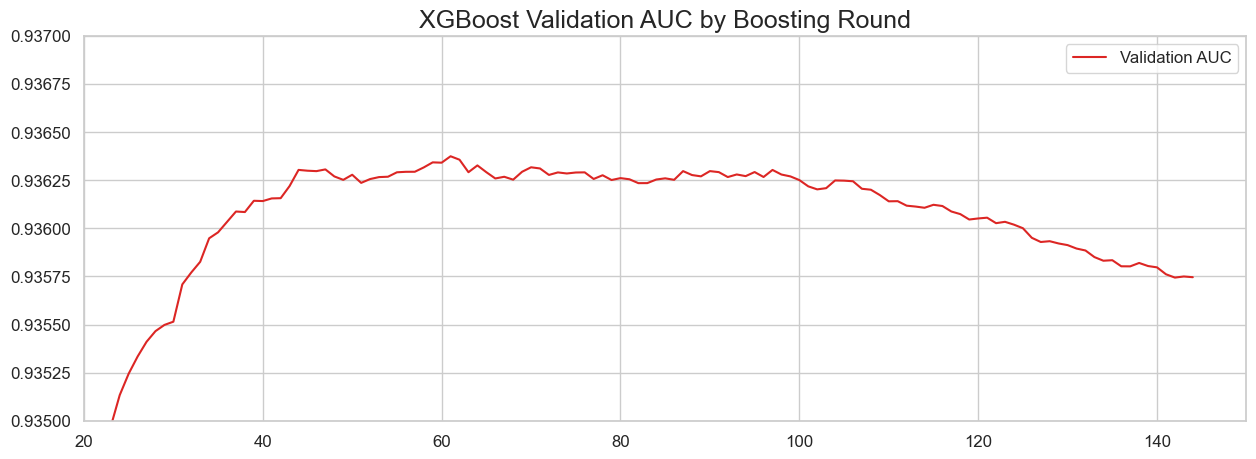

In [237]:
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(xgbcv.index, xgbcv["test-auc-mean"], c="#dc2624", label="Validation AUC")
plt.plot(xgbcv.index, xgbcv["test-auc-mean"] + xgbcv["test-auc-std"] * 5, c="pink", linestyle="dotted")
plt.plot(xgbcv.index, xgbcv["test-auc-mean"] - xgbcv["test-auc-std"] * 5, c="pink", linestyle="dotted")
plt.title("XGBoost Validation AUC by Boosting Round", fontsize=18)
plt.legend()
plt.ylim((0.935, 0.937))
plt.xlim((20, 150))
plt.show()

The fine XGBoost grid peaks at 60 rounds (`0.93634`), with 70 rounds nearly identical (`0.93629`). The source workflow's `num_boost_round=70` is retained because it lies on the same stable plateau.

In [238]:
# Original runtime estimate: approximately 15 minutes.
for num_round in [300,400,500,1000]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    
    rf = RFC(n_estimators=num_round,random_state=1412,class_weight={0:0.5,1:2})
    gbdc = GBC(n_estimators=num_round,random_state=1412)
    
    rfcv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    
    print(num_round)
    print("\t rf:{:.5f}".format(rfcv.mean()))
    print("\t gbd:{:.5f}".format(gbdcv.mean()))

300
	 rf:0.92929
	 gbd:0.93625


400
	 rf:0.92947
	 gbd:0.93667


500
	 rf:0.92964
	 gbd:0.93678


1000
	 rf:0.92988
	 gbd:0.93674


Random Forest and GBDT continue to improve as more trees are added. With unlimited compute, both might gain further, but 1,000 trees are already expensive on a personal computer.

- For GBDT, a larger learning rate may achieve similar performance with fewer trees.
- For Random Forest, controlling tree complexity may improve generalization and reduce per-tree cost.

At this stage, GBDT remains at 200 trees and Random Forest at 1,000 trees while learning rate is investigated.

#### Learning Rate

| Algorithm | Benchmark | Feature engineering | Class weighting | Tree-count search |
|---|---:|---:|---:|---:|
| Random Forest | 0.82892 | 0.92827 | 0.92897 | 0.92988 at 1,000 trees |
| GBDT | — | 0.93539 | — | 0.93678 at 500 trees |
| XGBoost | — | 0.93237 | 0.93503 | 0.93629 at 70 rounds |

Learning rate is one of the remaining parameters capable of materially affecting boosting performance. Random Forest has no learning-rate parameter, but GBDT uses `learning_rate` (default 0.1) and XGBoost uses `eta` (default 0.3). Both are evaluated across a broader range.

In [239]:
# Original runtime estimate: approximately 5 minutes.
for lr in [0.05,0.1,0.3,0.5]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    gbdc = GBC(n_estimators=200
               ,learning_rate=lr
               ,random_state=1412)
    param = {"objective":'binary:logistic',"eval_metric": "auc"
             ,"scale_pos_weight": 0.03
             ,"eta":lr}
    
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    xgbcv = xgb.cv(param, dtrain, num_boost_round=70, nfold=5, seed=1412, shuffle=True)
    test_auc = xgbcv.loc[69,"test-auc-mean"]
    
    print(lr)
    print("\t gbd:{:.5f}".format(gbdcv.mean()))
    print("\t xgb:{:.5f}".format(test_auc))

0.05
	 gbd:0.93346
	 xgb:0.93087


0.1
	 gbd:0.93539
	 xgb:0.93509


0.3
	 gbd:0.93605
	 xgb:0.93629


0.5
	 gbd:0.93438
	 xgb:0.93487


Increasing GBDT's learning rate from 0.1 toward 0.3 improves performance, while XGBoost does not clearly improve beyond its default neighborhood. A narrower search around 0.3 is performed next.

In [240]:
# Original runtime estimate: approximately 30 minutes.
gbdc_result = []
xgb_result = []
for lr in np.linspace(0.25,0.35,10):
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    gbdc = GBC(n_estimators=200
               ,learning_rate=lr
               ,random_state=1412)
    param = {"objective":'binary:logistic',"eval_metric": "auc"
             ,"scale_pos_weight": 0.03
             ,"eta":lr}
    
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    xgbcv = xgb.cv(param, dtrain, num_boost_round=70, nfold=5, seed=1412, shuffle=True)
    test_auc = xgbcv.loc[69,"test-auc-mean"]
    
    gbdc_result.append(gbdcv.mean())
    xgb_result.append(test_auc)

Best GBDT AUC: 0.93623; learning rate: 0.2611111111111111
Best XGBoost AUC: 0.93683; learning rate: 0.31666666666666665


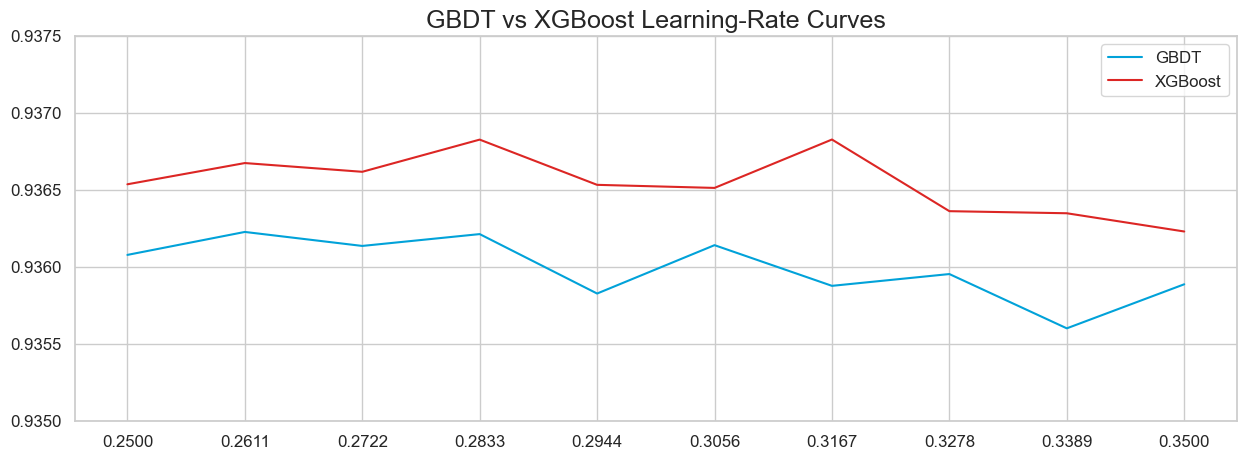

In [241]:
learning_rates = np.linspace(0.25, 0.35, 10)
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(learning_rates, gbdc_result, c="#01a2d9", label="GBDT")
plt.plot(learning_rates, xgb_result, c="#dc2624", label="XGBoost")
print(
    "Best GBDT AUC: {:.5f}; learning rate: {}".format(
        max(gbdc_result), learning_rates[gbdc_result.index(max(gbdc_result))]
    )
)
print(
    "Best XGBoost AUC: {:.5f}; learning rate: {}".format(
        max(xgb_result), learning_rates[xgb_result.index(max(xgb_result))]
    )
)
plt.title("GBDT vs XGBoost Learning-Rate Curves", fontsize=18)
plt.legend()
plt.xticks(learning_rates)
plt.ylim((0.935, 0.9375))
plt.show()

In [242]:
# Original runtime estimate: approximately 30 minutes.
gbdc_result2 = []
xgb_result2 = []
for lr in np.linspace(0.235,0.265,10):
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    gbdc = GBC(n_estimators=200
               ,learning_rate=lr
               ,random_state=1412)
    param = {"objective":'binary:logistic',"eval_metric": "auc"
             ,"scale_pos_weight": 0.03
             ,"eta":lr}
    
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    xgbcv = xgb.cv(param, dtrain, num_boost_round=70, nfold=5, seed=1412, shuffle=True)
    test_auc = xgbcv.loc[69,"test-auc-mean"]
    
    gbdc_result2.append(gbdcv.mean())
    xgb_result2.append(test_auc)

Best GBDT AUC: 0.93646; learning rate: 0.2383333333333333
Best XGBoost AUC: 0.93690; learning rate: 0.24166666666666667


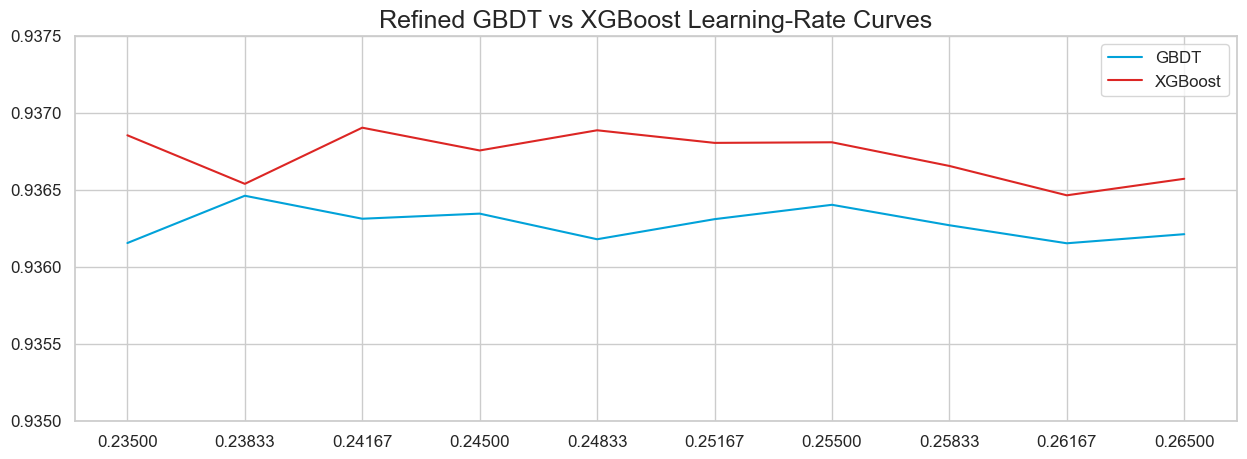

In [243]:
learning_rates = np.linspace(0.235, 0.265, 10)
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(learning_rates, gbdc_result2, c="#01a2d9", label="GBDT")
plt.plot(learning_rates, xgb_result2, c="#dc2624", label="XGBoost")
print(
    "Best GBDT AUC: {:.5f}; learning rate: {}".format(
        max(gbdc_result2), learning_rates[gbdc_result2.index(max(gbdc_result2))]
    )
)
print(
    "Best XGBoost AUC: {:.5f}; learning rate: {}".format(
        max(xgb_result2), learning_rates[xgb_result2.index(max(xgb_result2))]
    )
)
plt.title("Refined GBDT vs XGBoost Learning-Rate Curves", fontsize=18)
plt.legend()
plt.xticks(learning_rates)
plt.ylim((0.935, 0.9375))
plt.show()

The refined grids identify a current-environment optimum near `0.23833` for GBDT (`0.93646`) and `0.24167` for XGBoost (`0.93690`). The final workflow keeps GBDT close to the source setting (`0.26166`) and uses `0.24166` for XGBoost. These shallow score differences show why tuned values should be revalidated after library upgrades.

In [244]:
# Original runtime estimate: approximately 20 minutes.
gbdc_result = []
for num_round in [25,50,100,150,200,250]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    gbdc = GBC(n_estimators=num_round,learning_rate=0.26166,random_state=1412)
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    gbdc_result.append(gbdcv.mean())

Best GBDT AUC: 0.93622; trees: 250


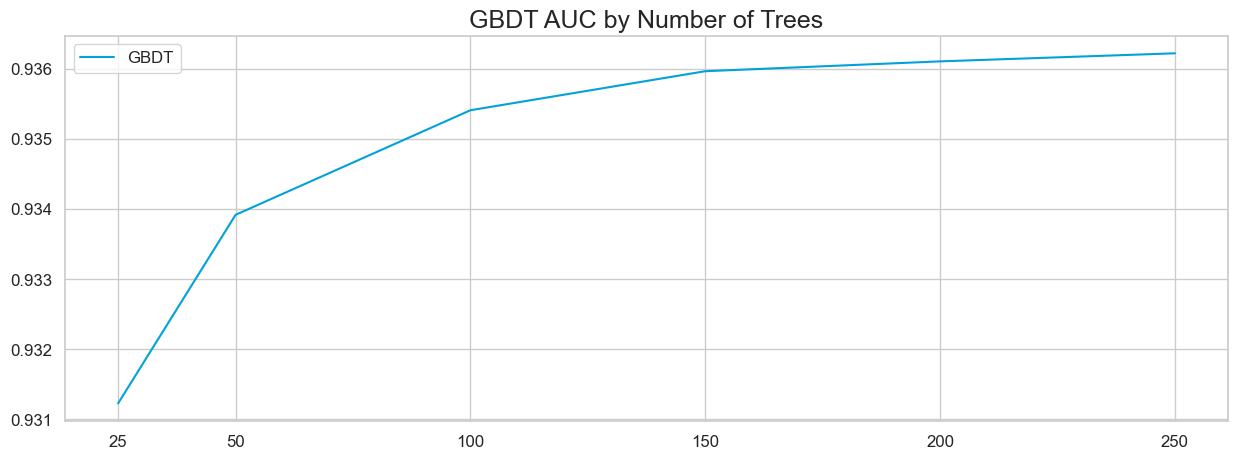

In [245]:
tree_counts = [25, 50, 100, 150, 200, 250]
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(tree_counts, gbdc_result, c="#01a2d9", label="GBDT")
print(
    "Best GBDT AUC: {:.5f}; trees: {}".format(
        max(gbdc_result), tree_counts[gbdc_result.index(max(gbdc_result))]
    )
)
plt.title("GBDT AUC by Number of Trees", fontsize=18)
plt.legend()
plt.xticks(tree_counts)
plt.show()

With the selected learning-rate neighborhood, the tested GBDT grid reaches `0.93622` at 250 trees. The workflow retains 200 trees as a compute-performance compromise rather than claiming it is the absolute maximum in the current run.

#### Controlling Overfitting

| Algorithm | Feature-engineering AUC | Selected tuning-stage AUC |
|---|---:|---:|
| Random Forest | 0.92827 | 0.92988 before depth tuning |
| GBDT | 0.93539 | up to 0.93646 in the learning-rate grid |
| XGBoost | 0.93237 | up to 0.93690 in the refined learning-rate grid |

In [246]:
rf = RFC(n_estimators=1000
         ,random_state=1412
         ,class_weight={0:0.5,1:2})
gbdc = GBC(n_estimators=200
           ,learning_rate=0.26166
           ,random_state=1412)

param = {"objective":'binary:logistic'
         ,"eval_metric": "auc"
         ,"eta":0.24166
         ,"scale_pos_weight": 0.03}
xgbcv = xgb.cv(param, dtrain, num_boost_round=70, nfold=5, seed=1412, shuffle=True)

After tuning several parameters, investigate overfitting. XGBoost's cross-validation output includes both training and validation metrics, allowing their gap to be visualized directly.

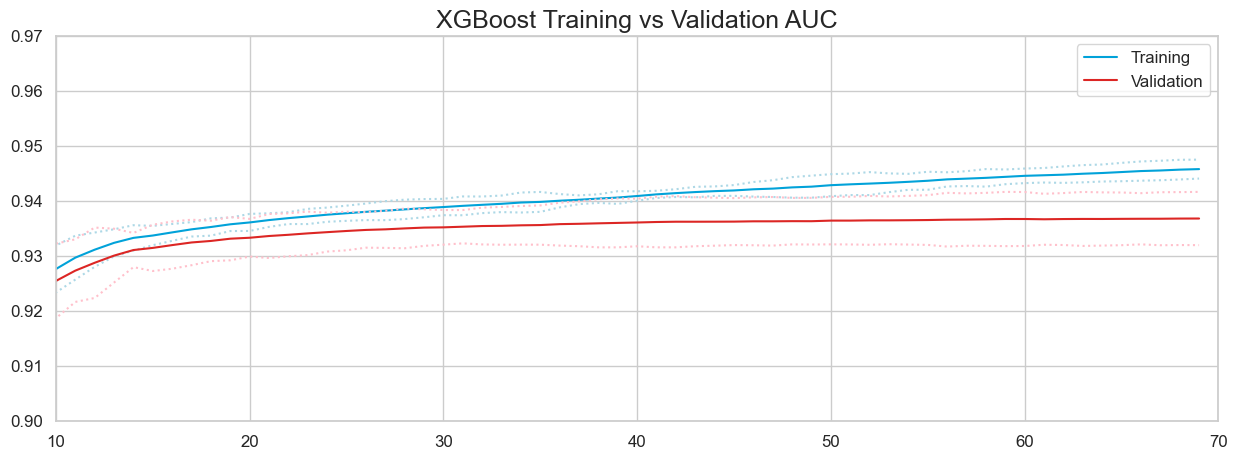

In [247]:
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(xgbcv.index, xgbcv["train-auc-mean"], c="#01a2d9", label="Training")
plt.plot(xgbcv.index, xgbcv["train-auc-mean"] + xgbcv["train-auc-std"] * 5, c="lightblue", linestyle="dotted")
plt.plot(xgbcv.index, xgbcv["train-auc-mean"] - xgbcv["train-auc-std"] * 5, c="lightblue", linestyle="dotted")
plt.plot(xgbcv.index, xgbcv["test-auc-mean"], c="#dc2624", label="Validation")
plt.plot(xgbcv.index, xgbcv["test-auc-mean"] + xgbcv["test-auc-std"] * 5, c="pink", linestyle="dotted")
plt.plot(xgbcv.index, xgbcv["test-auc-mean"] - xgbcv["test-auc-std"] * 5, c="pink", linestyle="dotted")
plt.title("XGBoost Training vs Validation AUC", fontsize=18)
plt.legend()
plt.xlim(10, 70)
plt.ylim((0.9, 0.97))
plt.show()

The XGBoost train-validation gap is moderate, partly because the model is limited to 70 rounds and because defaults such as `max_depth=6` already regularize complexity. Additional overfitting controls may therefore offer limited benefit.

Scikit-learn's standard `cross_val_score` does not expose training-fold predictions here, so overfitting in Random Forest and GBDT cannot be plotted in the same way. Their much larger tree counts suggest that explicit complexity control is still worth testing.

Tree models provide many regularization parameters because their learning capacity makes them prone to overfitting. `max_depth` is one of the strongest controls. If shallower trees improve validation AUC, other regularization parameters may also be useful; if performance only worsens, further regularization may be unnecessary.

GBDT already defaults to shallow trees (`max_depth=3`), whereas Random Forest defaults to unlimited depth. Reducing maximum depth is therefore especially relevant for the forest.

In [248]:
# Original runtime estimate: approximately 40 minutes.
for max_depth in [5,10,15,20,25,30]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    
    rf = RFC(n_estimators=1000,max_depth=max_depth,random_state=1412,class_weight={0:0.5,1:2})
    gbdc = GBC(n_estimators=200,max_depth=max_depth,learning_rate=0.26166,random_state=1412)
    param = {"objective":'binary:logistic',"eval_metric": "auc","max_depth" : max_depth
             ,"eta":0.24166,"scale_pos_weight": 0.03}
    
    rfcv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    gbdcv = cross_val_score(gbdc,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    xgbcv = xgb.cv(param, dtrain, num_boost_round=70, nfold=5, seed=1412, shuffle=True)
    test_auc = xgbcv.loc[69,"test-auc-mean"]
    
    print(max_depth)
    print("\t rf:{:.5f}".format(rfcv.mean()))
    print("\t gbd:{:.5f}".format(gbdcv.mean()))
    print("\t xgb:{:.5f}".format(test_auc))

5
	 rf:0.90926
	 gbd:0.93521
	 xgb:0.93625


10
	 rf:0.93124
	 gbd:0.92785
	 xgb:0.93671


15
	 rf:0.93300
	 gbd:0.92676
	 xgb:0.93547


20
	 rf:0.93081
	 gbd:0.92664
	 xgb:0.93498


25
	 rf:0.93026
	 gbd:0.92530
	 xgb:0.93493


30
	 rf:0.92999
	 gbd:0.91357
	 xgb:0.93478


With very shallow trees, Random Forest AUC is below 0.90. At a depth of 10, it rises above 0.93 for the first time, indicating that the unrestricted forest was overfitting and that depth control improves generalization.

GBDT and XGBoost do not surpass their earlier results in this broad depth grid. Because both already outperform the forest, the next step focuses on refining Random Forest depth so that model fusion benefits from three comparably strong components.

In [249]:
# Original runtime estimate: approximately 70 minutes.
result = []
for max_depth in range(10,21):
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    rf = RFC(n_estimators=1000,max_depth=max_depth,random_state=1412,class_weight={0:0.5,1:2})    
    rfcv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    result.append(rfcv.mean())

Best Random Forest AUC: 0.93365; max_depth: 13


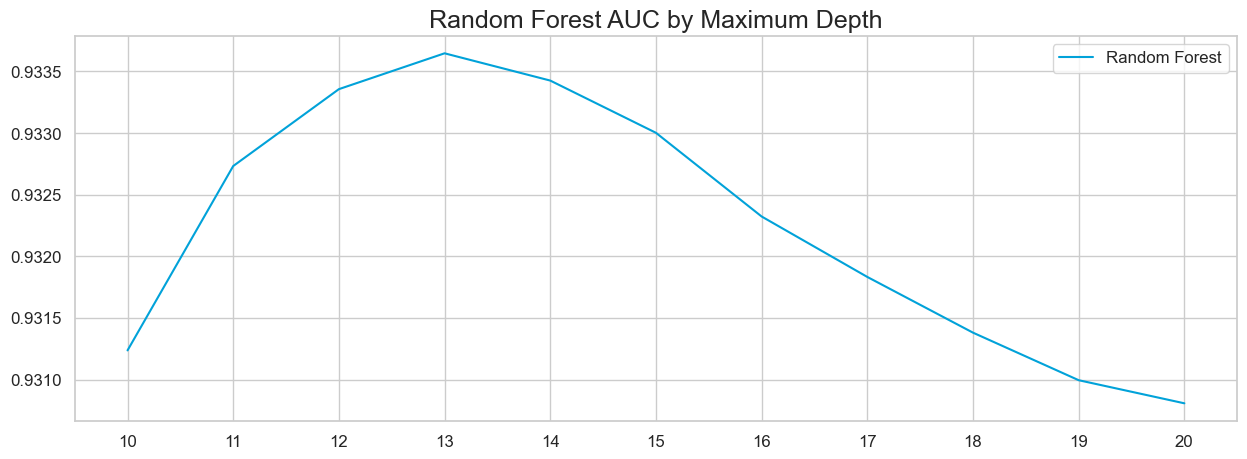

In [250]:
depth_values = list(range(10, 21))
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(depth_values, result, c="#01a2d9", label="Random Forest")
print(
    "Best Random Forest AUC: {:.5f}; max_depth: {}".format(
        max(result), depth_values[result.index(max(result))]
    )
)
plt.title("Random Forest AUC by Maximum Depth", fontsize=18)
plt.legend()
plt.xticks(depth_values)
plt.show()

Random Forest performs best at `max_depth=13`, reaching `0.93365`. With depth regularization fixed, tree count is revisited to see whether a smaller forest can preserve most of the gain.

In [251]:
# Original runtime estimate: approximately 10 minutes.
rf_result = []
for num_round in [100,200,300,400,500]:
    cv = KFold(n_splits=5,shuffle=True,random_state=1412)
    rf = RFC(n_estimators=num_round,max_depth=13,random_state=1412,class_weight={0:0.5,1:2})
    rfcv = cross_val_score(rf,Xtrain,Ytrain,cv=cv,n_jobs=N_JOBS,scoring="roc_auc")
    rf_result.append(rfcv.mean())

Best Random Forest AUC: 0.93353; trees: 500


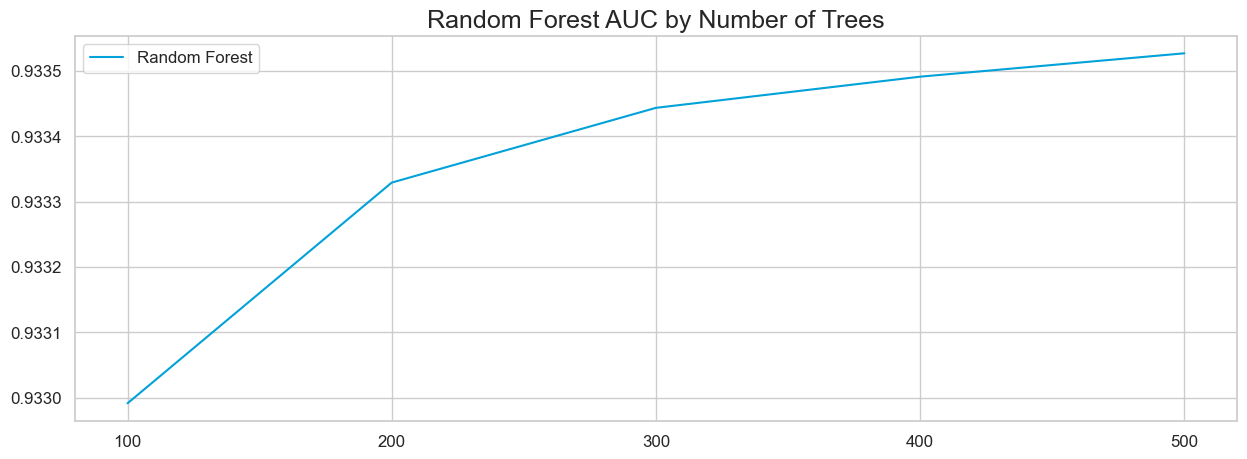

In [252]:
tree_counts = [100, 200, 300, 400, 500]
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(tree_counts, rf_result, c="#01a2d9", label="Random Forest")
print(
    "Best Random Forest AUC: {:.5f}; trees: {}".format(
        max(rf_result), tree_counts[rf_result.index(max(rf_result))]
    )
)
plt.title("Random Forest AUC by Number of Trees", fontsize=18)
plt.legend()
plt.xticks(tree_counts)
plt.show()

Validation AUC still increases gradually with more trees, but 500 trees reach `0.93353`. Increasing model size further offers only a very small expected gain relative to computational cost. The final Random Forest therefore uses 500 trees.

Further parameters such as `max_features` and `min_samples_split` could be tuned, but the next objective is model fusion. The selected individual models are sufficiently strong for that stage.

| Algorithm | Benchmark | Feature engineering | Intermediate tuning | Final selected-stage CV AUC |
|---|---:|---:|---:|---:|
| Random Forest | 0.82892 | 0.92827 | 0.92988 at 1,000 trees | 0.93353 with 500 trees and depth 13 |
| GBDT | — | 0.93539 | up to 0.93646 in the learning-rate grid | 200 trees retained for efficiency |
| XGBoost | — | 0.93237 | 0.93629 at 70 rounds | up to 0.93690 in the learning-rate grid |

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import roc_auc_score, accuracy_score
import xgboost as xgb

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)

In [254]:
train = pd.read_csv("data/train_en.csv")
test = pd.read_csv("data/test_en.csv")

In [255]:
Xtrain = train.iloc[:,1:]
Xtest = test.iloc[:,1:]
Ytrain = train.iloc[:,0]
Ytest = test.iloc[:,0]

dtrain = xgb.DMatrix(Xtrain,Ytrain)
dtest = xgb.DMatrix(Xtest,Ytest)

The tuning process has produced three models with strong estimated generalization. Scikit-learn models can be combined with `VotingClassifier`, but this notebook trains XGBoost through its native API, so voting is implemented manually.

The simplified final evaluation trains each model once on the full training set and evaluates the combined probabilities on the held-out Order-ID test set.

#### Soft Voting and Hard Voting

Hard voting selects the majority predicted class. Soft voting combines predicted probabilities and selects the class with the larger aggregate probability. The following toy example illustrates the distinction.

In [256]:
hard = pd.DataFrame(
    [["RF", 1], ["GBDT", 1], ["XGB", 0]],
    columns=["Model", "Predicted Label"],
)

In [257]:
soft = pd.DataFrame(
    [["RF", 0.34, 0.66], ["GBDT", 0.6, 0.4], ["XGB", 0.2, 0.8]],
    columns=["Model", 0, 1],
)

In [258]:
hard

,Model,Predicted Label
0,RF,1
1,GBDT,1
2,XGB,0


In [259]:
soft

,Model,0,1
0,RF,0.34,0.66
1,GBDT,0.60,0.40
2,XGB,0.20,0.80


Under hard voting, two of the three models predict class 1, so the ensemble predicts class 1.

In [260]:
hard["Predicted Label"].value_counts().index[0]

np.int64(1)

Under soft voting, probabilities are combined by class and the class with the larger aggregate score is selected.

In [261]:
soft.loc[:, [0, 1]].sum(axis=0)

0    1.14
1    1.86
dtype: float64

In [262]:
soft.loc[:, [0, 1]].sum(axis=0).values.tolist()

[1.14, 1.86]

In [263]:
np.argmax(soft.loc[:, [0, 1]].sum(axis=0).values.tolist())

np.int64(1)

Soft voting is especially useful when component models are well calibrated or carefully tuned, while hard voting can be adequate for default classifiers. The three tuned models are combined here with weighted soft voting. Each model is first fitted on the training set and used to generate class probabilities for both training and test data.

In [264]:
# Tuned component models.
rf = RFC(
    n_estimators=500,
    max_depth=13,
    class_weight={0: 0.5, 1: 2},
    random_state=1412,
    n_jobs=-1,
)
gbdc = GBC(n_estimators=200, learning_rate=0.26166, random_state=1412)
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.24166,
    "scale_pos_weight": 0.03,
    "seed": 1412,
}

In [265]:
# Fit all three models on the training set.
rf = rf.fit(Xtrain, Ytrain)
gbdc = gbdc.fit(Xtrain, Ytrain)
xgbc = xgb.train(xgb_params, dtrain, num_boost_round=70)

In [266]:
# Generate training-set probabilities.
rf_prob_train = rf.predict_proba(Xtrain)
gbdc_prob_train = gbdc.predict_proba(Xtrain)
xgb_prob_train = xgbc.predict(dtrain)

In [267]:
xgb_prob_train # One column: probability of class 1.

array([0.13703938, 0.01763542, 0.00182496, ..., 0.01339558, 0.00037005,
       0.00235315], dtype=float32)

In [268]:
rf_prob_train # First column is class 0; second is class 1.

array([[0.33617004, 0.66382996],
       [0.40395655, 0.59604345],
       [0.86123533, 0.13876467],
       ...,
       [0.69039893, 0.30960107],
       [0.84794703, 0.15205297],
       [0.72446574, 0.27553426]])

In [269]:
gbdc_prob_train # Same two-column convention as Random Forest.

array([[0.07610924, 0.92389076],
       [0.65218273, 0.34781727],
       [0.99040054, 0.00959946],
       ...,
       [0.89969044, 0.10030956],
       [0.99751732, 0.00248268],
       [0.97669169, 0.02330831]])

In [270]:
# Compare training ROC AUC values to choose ensemble weights.
# Random Forest scores highest, followed by GBDT and XGBoost.
# Assign the largest ensemble weight to Random Forest.

In [271]:
roc_auc_score(Ytrain,rf_prob_train[:,1])

np.float64(0.9629152093972801)

In [272]:
roc_auc_score(Ytrain,gbdc_prob_train[:,1])

np.float64(0.9449516462086154)

In [273]:
roc_auc_score(Ytrain,xgb_prob_train)

np.float64(0.9450049487105041)

In [274]:
# Training-set soft voting.
prob_train = pd.concat([pd.DataFrame(rf_prob_train,columns=["rf0","rf1"])
                        ,pd.DataFrame(gbdc_prob_train,columns=["gbc0","gbc1"])
                        ,pd.DataFrame(xgb_prob_train,columns=["xgb1"])]
                                      ,axis=1)

In [275]:
prob_train.head()

,rf0,rf1,gbc0,gbc1,xgb1
0,0.336170,0.663830,0.076109,0.923891,0.137039
1,0.403957,0.596043,0.652183,0.347817,0.017635
2,0.861235,0.138765,0.990401,0.009599,0.001825
3,0.542405,0.457595,0.810818,0.189182,0.009765
4,0.722593,0.277407,0.741707,0.258293,0.008749


In [276]:
# Derive XGBoost's class-0 probability.
prob_train["xgb0"] = 1 - prob_train["xgb1"]

In [277]:
prob_train.head()

,rf0,rf1,gbc0,gbc1,xgb1,xgb0
0,0.336170,0.663830,0.076109,0.923891,0.137039,0.862961
1,0.403957,0.596043,0.652183,0.347817,0.017635,0.982365
2,0.861235,0.138765,0.990401,0.009599,0.001825,0.998175
3,0.542405,0.457595,0.810818,0.189182,0.009765,0.990235
4,0.722593,0.277407,0.741707,0.258293,0.008749,0.991251


In [278]:
# Compute the weighted class-0 score.
prob_train.loc[:,"0"] = 4*prob_train.loc[:,"rf0"] + 0.8*prob_train.loc[:,"gbc0"] + 0.2*prob_train.loc[:,"xgb0"]

In [279]:
# Compute the weighted class-1 score.
prob_train.loc[:,"1"] = 4*prob_train.loc[:,"rf1"] + 0.8*prob_train.loc[:,"gbc1"] + 0.2*prob_train.loc[:,"xgb1"]

In [280]:
prob_train.head()

,rf0,rf1,gbc0,gbc1,xgb1,xgb0,0,1
0,0.336170,0.663830,0.076109,0.923891,0.137039,0.862961,1.578160,3.421840
1,0.403957,0.596043,0.652183,0.347817,0.017635,0.982365,2.334045,2.665955
2,0.861235,0.138765,0.990401,0.009599,0.001825,0.998175,4.436897,0.563103
3,0.542405,0.457595,0.810818,0.189182,0.009765,0.990235,3.016321,1.983679
4,0.722593,0.277407,0.741707,0.258293,0.008749,0.991251,3.681989,1.318011


In [281]:
# Normalize the class-1 score to the [0, 1] interval.
prob_train["adjusted1"] = prob_train["1"]/(prob_train["0"] + prob_train["1"])

In [282]:
prob_train.head()

,rf0,rf1,gbc0,gbc1,xgb1,xgb0,0,1,adjusted1
0,0.336170,0.663830,0.076109,0.923891,0.137039,0.862961,1.578160,3.421840,0.684368
1,0.403957,0.596043,0.652183,0.347817,0.017635,0.982365,2.334045,2.665955,0.533191
2,0.861235,0.138765,0.990401,0.009599,0.001825,0.998175,4.436897,0.563103,0.112621
3,0.542405,0.457595,0.810818,0.189182,0.009765,0.990235,3.016321,1.983679,0.396736
4,0.722593,0.277407,0.741707,0.258293,0.008749,0.991251,3.681989,1.318011,0.263602


In [283]:
# Calculate AUC.
roc_auc_score(Ytrain,prob_train["adjusted1"]) # Highest training AUC observed in the workflow.

np.float64(0.9607725373802903)

In [284]:
# Calculate accuracy.
Ytrain_pred = ((prob_train["adjusted1"]) > 0.5).astype("int")

In [285]:
accuracy_score(Ytrain,Ytrain_pred)

0.8905712544084992

In [286]:
# Adjust the decision threshold.
Ytrain_pred = ((prob_train["adjusted1"]) > 0.7).astype("int")

In [287]:
accuracy_score(Ytrain,Ytrain_pred)

0.9029803631297079

| Model | Relevant measured result |
|---|---:|
| Random Forest training AUC | 0.96292 |
| GBDT training AUC | 0.94495 |
| XGBoost training AUC | 0.94500 |
| Weighted soft-voting training AUC | **0.96077** |

The training-set score shows that weighted probability fusion captures complementary strengths across the three component models. The held-out Order-ID test set is required to assess whether that gain generalizes.

In [288]:
# Generate held-out test probabilities.
rf_prob_test = rf.predict_proba(Xtest)
gbdc_prob_test = gbdc.predict_proba(Xtest)
xgb_prob_test = xgbc.predict(dtest)

In [289]:
# Test-set soft voting.
prob_test = pd.concat([pd.DataFrame(rf_prob_test,columns=["rf0","rf1"])
                        ,pd.DataFrame(gbdc_prob_test,columns=["gbc0","gbc1"])
                        ,pd.DataFrame(xgb_prob_test,columns=["xgb1"])]
                                      ,axis=1)

In [290]:
prob_test["xgb0"] = 1 - prob_test["xgb1"]

In [291]:
prob_test.loc[:,"0"] = 4*prob_test.loc[:,"rf0"] + 0.8*prob_test.loc[:,"gbc0"] + 0.2*prob_test.loc[:,"xgb0"]

In [292]:
prob_test.loc[:,"1"] = 4*prob_test.loc[:,"rf1"] + 0.8*prob_test.loc[:,"gbc1"] + 0.2*prob_test.loc[:,"xgb1"]

In [293]:
prob_test["adjusted1"] = prob_test["1"]/(prob_test["0"] + prob_test["1"])

In [294]:
roc_auc_score(Ytest,prob_test["adjusted1"])

np.float64(0.8150374820634811)

In [295]:
Ytest_pred = ((prob_test["adjusted1"]) > 0.7).astype("int")

In [296]:
accuracy_score(Ytest,Ytest_pred)

0.8158268635510225

The ensemble performs reasonably on the held-out test set, although the training score remains much higher, indicating residual overfitting. Even so, the test performance can support an operational early-warning system.

The training and test distributions may differ substantially because new orders can contain users, products, or other categories absent from historical data. Possible next steps include:

- Apply order-level consistency rules so all lines under the same Order ID receive a coherent final label.
- Continue targeted hyperparameter tuning.
- Add more leakage-safe aggregate and interaction features.
- Train additional diverse models and expand the ensemble.

The current pipeline provides a strong, reproducible foundation for further model refinement and business calibration.

### 4.1 Final Interpretation: XGBoost and the Fused Model

- The refined XGBoost learning-rate grid reaches a five-fold cross-validation AUC of approximately `0.93690`.
- Weighted soft voting achieves a held-out Order-ID test AUC of `0.81504` and test accuracy of `0.81583` at a threshold of 0.7.
- The weighted ensemble's training AUC is `0.96077`, so the train-test gap indicates residual overfitting and distribution shift.
- In production, the classification threshold should reflect review cost and risk tolerance: a higher threshold reduces false positives but lowers recall, while a lower threshold increases coverage at the cost of more false alerts.